# 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## importing data

In [4]:
file_addr = 'try.csv'
dataset  = pd.read_csv(file_addr)
dataset

,date,hostel,meal,pwaste,twaste,foodsample,kwaste,hostel type
0,02-03-2025,A,breakfast,6.80,1.8,0.5,0.100,girls
1,02-03-2025,B,breakfast,5.30,2.4,0.6,7.600,boys
2,02-03-2025,C,breakfast,3.10,1.6,0.8,0.011,boys
3,02-03-2025,D,breakfast,13.11,2.6,0.8,3.800,boys
4,02-03-2025,FRG,breakfast,4.11,NaN,NaN,2.500,boys
...,...,...,...,...,...,...,...,...
145,06-03-2025,M,dinner,13.60,5.7,0.6,6.900,boys
146,06-03-2025,N,dinner,6.50,3.0,0.6,3.600,girls
147,06-03-2025,O,dinner,15.40,4.3,0.6,9.200,boys
148,06-03-2025,PG,dinner,6.50,NaN,NaN,4.200,girls


## Data-preprocessing

In [5]:
dataset.isnull().sum()

date            0
hostel          0
meal            0
pwaste          4
twaste         32
foodsample     33
kwaste          9
hostel type     0
dtype: int64

One

### filling up missing values with their median

In [6]:
dataset[['pwaste', 'kwaste', 'foodsample', 'twaste']] = (dataset[['pwaste', 'kwaste', 'foodsample', 'twaste']]).apply(lambda col:col.fillna(col.median()) if col.dtype != 'O' else col)
dataset

,date,hostel,meal,pwaste,twaste,foodsample,kwaste,hostel type
0,02-03-2025,A,breakfast,6.80,1.8,0.5,0.100,girls
1,02-03-2025,B,breakfast,5.30,2.4,0.6,7.600,boys
2,02-03-2025,C,breakfast,3.10,1.6,0.8,0.011,boys
3,02-03-2025,D,breakfast,13.11,2.6,0.8,3.800,boys
4,02-03-2025,FRG,breakfast,4.11,4.3,0.6,2.500,boys
...,...,...,...,...,...,...,...,...
145,06-03-2025,M,dinner,13.60,5.7,0.6,6.900,boys
146,06-03-2025,N,dinner,6.50,3.0,0.6,3.600,girls
147,06-03-2025,O,dinner,15.40,4.3,0.6,9.200,boys
148,06-03-2025,PG,dinner,6.50,4.3,0.6,4.200,girls


In [7]:
dataset.isnull().sum()

date           0
hostel         0
meal           0
pwaste         0
twaste         0
foodsample     0
kwaste         0
hostel type    0
dtype: int64

### Encoding Categorical Data

#### OneHotEncoding on 'meal'

In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# one_hot_encoder = OneHotEncoder(sparse_output=False)

# one_hot_encoded_meal = one_hot_encoder.fit_transform(dataset[['meal']]) # we apply double square brackets as to not pass a 'series', to make a dataframe we use this approach

# one_hot_encoded_meal

transformer = ColumnTransformer(
    transformers=[
        ('ohe_meal', OneHotEncoder(sparse_output=False),['meal'])
    ],
    remainder='passthrough'
)

df_transformed = transformer.fit_transform(dataset)

encoded_column_names = (transformer.named_transformers_['ohe_meal'].get_feature_names_out(['meal']))
remainder_column_names = dataset.columns.difference(['meal'], sort = False).to_list()

new_column_names = list(encoded_column_names) + remainder_column_names

dataset = pd.DataFrame(df_transformed, columns=new_column_names)

dataset

,meal_breakfast,meal_dinner,meal_lunch,date,hostel,pwaste,twaste,foodsample,kwaste,hostel type
0,1.0,0.0,0.0,02-03-2025,A,6.8,1.8,0.5,0.1,girls
1,1.0,0.0,0.0,02-03-2025,B,5.3,2.4,0.6,7.6,boys
2,1.0,0.0,0.0,02-03-2025,C,3.1,1.6,0.8,0.011,boys
3,1.0,0.0,0.0,02-03-2025,D,13.11,2.6,0.8,3.8,boys
4,1.0,0.0,0.0,02-03-2025,FRG,4.11,4.3,0.6,2.5,boys
...,...,...,...,...,...,...,...,...,...,...
145,0.0,1.0,0.0,06-03-2025,M,13.6,5.7,0.6,6.9,boys
146,0.0,1.0,0.0,06-03-2025,N,6.5,3.0,0.6,3.6,girls
147,0.0,1.0,0.0,06-03-2025,O,15.4,4.3,0.6,9.2,boys
148,0.0,1.0,0.0,06-03-2025,PG,6.5,4.3,0.6,4.2,girls


#### Binary Encoding on 'hostel'

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataset['hostel'] = le.fit_transform(dataset['hostel'])

def int_to_binary(n, bits):
    return list(np.binary_repr(n, width=bits))

numberOfBits = len(np.binary_repr(dataset['hostel'].max()))

binary_hostel = dataset['hostel'].apply(lambda x: int_to_binary(x, numberOfBits))

binary_hostel = pd.DataFrame(binary_hostel.tolist(), columns = [f'hostel_binary_{i}' for i in range(numberOfBits)])

dataset = pd.concat([dataset.drop(columns = ['hostel']), binary_hostel], axis = 1)

dataset

,meal_breakfast,meal_dinner,meal_lunch,date,pwaste,twaste,foodsample,kwaste,hostel type,hostel_binary_0,hostel_binary_1,hostel_binary_2,hostel_binary_3
0,1.0,0.0,0.0,02-03-2025,6.8,1.8,0.5,0.1,girls,0,0,0,0
1,1.0,0.0,0.0,02-03-2025,5.3,2.4,0.6,7.6,boys,0,0,0,1
2,1.0,0.0,0.0,02-03-2025,3.1,1.6,0.8,0.011,boys,0,0,1,0
3,1.0,0.0,0.0,02-03-2025,13.11,2.6,0.8,3.8,boys,0,0,1,1
4,1.0,0.0,0.0,02-03-2025,4.11,4.3,0.6,2.5,boys,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0.0,1.0,0.0,06-03-2025,13.6,5.7,0.6,6.9,boys,0,1,0,1
146,0.0,1.0,0.0,06-03-2025,6.5,3.0,0.6,3.6,girls,0,1,1,0
147,0.0,1.0,0.0,06-03-2025,15.4,4.3,0.6,9.2,boys,0,1,1,1
148,0.0,1.0,0.0,06-03-2025,6.5,4.3,0.6,4.2,girls,1,0,0,0


In [10]:
dataset.columns

Index(['meal_breakfast', 'meal_dinner', 'meal_lunch', 'date', 'pwaste',
       'twaste', 'foodsample', 'kwaste', 'hostel type', 'hostel_binary_0',
       'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3'],
      dtype='object')

#### One Hot Encoding 'hostel type'

In [11]:
dataset['hostel type']

0      girls
1       boys
2       boys
3       boys
4       boys
       ...  
145     boys
146    girls
147     boys
148    girls
149    girls
Name: hostel type, Length: 150, dtype: object

In [12]:
transformer = ColumnTransformer(
    transformers=[
        ('ohe_hostel_type', OneHotEncoder(sparse_output=False),['hostel type'])
    ],
    remainder = 'passthrough'
)

dataset_transformed = transformer.fit_transform(dataset)

encoded_cols_names = transformer.named_transformers_['ohe_hostel_type'].get_feature_names_out(['hostel type'])
remiander_cols_names = dataset.columns.difference(['hostel type'], sort = False).to_list()

col_names = list(encoded_cols_names) + remiander_cols_names

dataset = pd.DataFrame(dataset_transformed, columns = col_names)

dataset

,hostel type_boys,hostel type_girls,meal_breakfast,meal_dinner,meal_lunch,date,pwaste,twaste,foodsample,kwaste,hostel_binary_0,hostel_binary_1,hostel_binary_2,hostel_binary_3
0,0.0,1.0,1.0,0.0,0.0,02-03-2025,6.8,1.8,0.5,0.1,0,0,0,0
1,1.0,0.0,1.0,0.0,0.0,02-03-2025,5.3,2.4,0.6,7.6,0,0,0,1
2,1.0,0.0,1.0,0.0,0.0,02-03-2025,3.1,1.6,0.8,0.011,0,0,1,0
3,1.0,0.0,1.0,0.0,0.0,02-03-2025,13.11,2.6,0.8,3.8,0,0,1,1
4,1.0,0.0,1.0,0.0,0.0,02-03-2025,4.11,4.3,0.6,2.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,1.0,0.0,0.0,1.0,0.0,06-03-2025,13.6,5.7,0.6,6.9,0,1,0,1
146,0.0,1.0,0.0,1.0,0.0,06-03-2025,6.5,3.0,0.6,3.6,0,1,1,0
147,1.0,0.0,0.0,1.0,0.0,06-03-2025,15.4,4.3,0.6,9.2,0,1,1,1
148,0.0,1.0,0.0,1.0,0.0,06-03-2025,6.5,4.3,0.6,4.2,1,0,0,0


## Data Insights

In [13]:
sns.set_style("darkgrid", {
    'axes.facecolor' : 'black',
    'figure.facecolor' : 'black',
    'grid.color' : 'white'
})


In [14]:
# df_long = pd.melt(dataset, id_vars="date", value_vars = ["twaste", "pwaste", "kwaste", "foodsample"], value_name="waste in kgs", var_name = "waste")
# df_long

In [15]:
# sns.barplot(df_long, x = "date", y = "waste in kgs", hue = "waste", palette="colorblind")
# sns.lineplot(dataset, x = "date", y = dataset.loc[:, 'pwaste'])
# plt.title("waste generated v/s dates", color = "white")
# plt.xticks(color = "white")
# plt.yticks(color = "white")
# plt.xlabel('dates', color = 'white')
# plt.ylabel('waste in kgs', color = 'white')
# legend = plt.legend()
# legend.set_title("waste")
# for text in legend.get_texts():
#     text.set_color('white')
# if legend.get_title():
#     legend.get_title().set_color('white')
# plt.show()

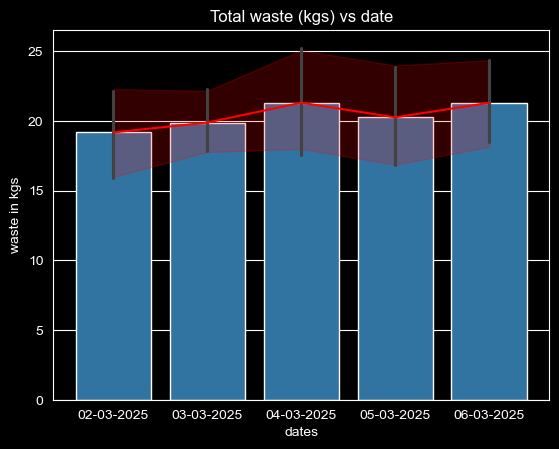

In [16]:
total_waste = dataset.loc[:, 'twaste'] + dataset.loc[:, 'pwaste'] + dataset.loc[:, 'foodsample'] + dataset.loc[:, 'kwaste']
sns.barplot(dataset, x = dataset.loc[:, 'date'], y = total_waste)
sns.lineplot(dataset, x = dataset.loc[:, 'date'], y = total_waste, color = 'red')
plt.title("Total waste (kgs) vs date", color = 'white')
plt.xlabel('dates', color = 'white')
plt.ylabel('waste in kgs', color = 'white')
plt.xticks(color = 'white')
plt.yticks(color = 'white')
plt.show()

In [17]:
total = dataset.loc[:, 'twaste'] + dataset.loc[:, 'pwaste'] + dataset.loc[:, 'kwaste'] + dataset.loc[:, 'foodsample']
print(total.shape)
dataset.shape


(150,)


(150, 14)

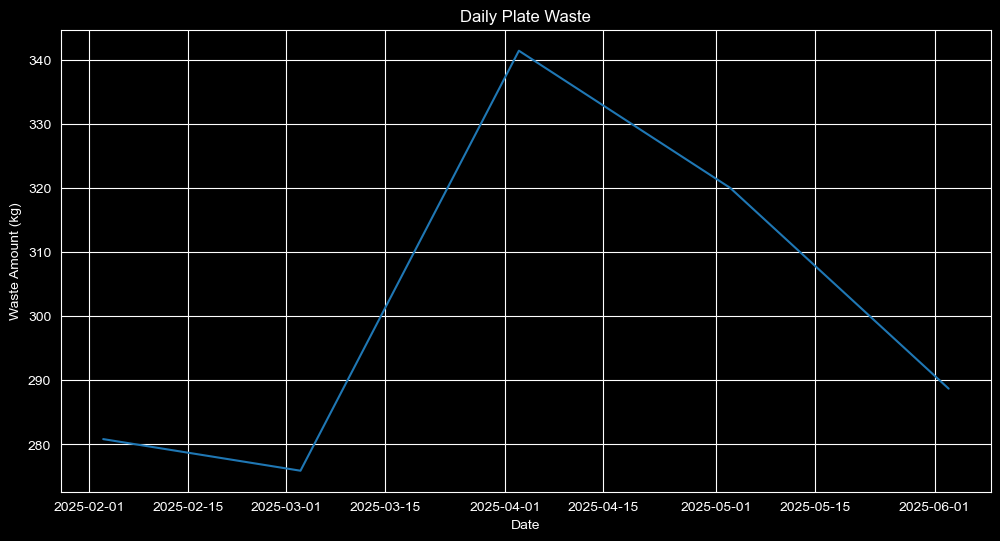

C:\Users\karan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\karan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\karan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\karan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

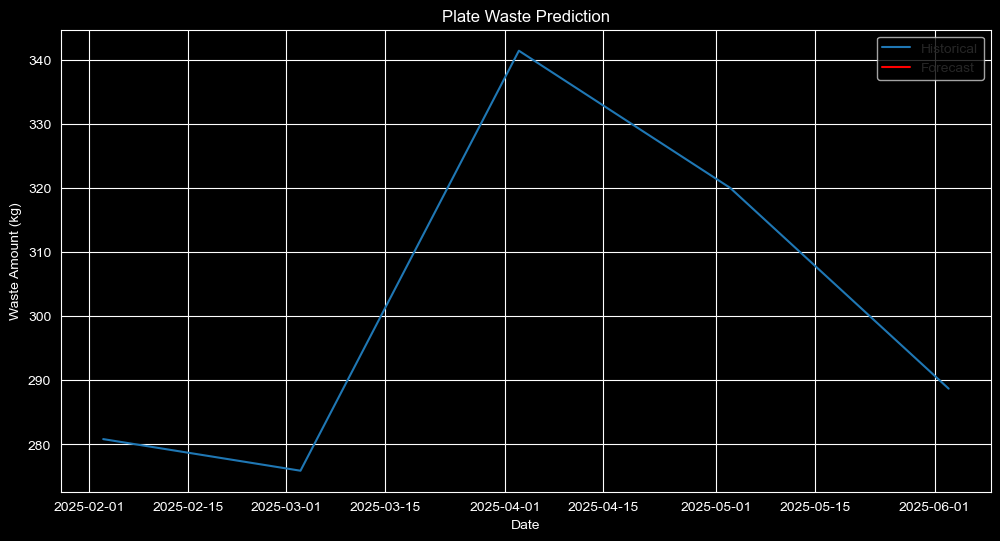

Forecast for the next 7 days:
2025-06-04   NaN
2025-06-05   NaN
2025-06-06   NaN
2025-06-07   NaN
2025-06-08   NaN
2025-06-09   NaN
2025-06-10   NaN
Freq: D, Name: predicted_mean, dtype: float64


In [18]:
# Time-based prediction approaches
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# First, reset index to get date as a column again
dataset_ts = dataset.reset_index()

# Convert date to datetime format
dataset_ts['date'] = pd.to_datetime(dataset_ts['date'])

# Aggregate waste by date for time series analysis
daily_waste = dataset_ts.groupby('date')['pwaste'].sum()

# Make sure data is numeric and clean
daily_waste = pd.to_numeric(daily_waste, errors='coerce').fillna(daily_waste.median())

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(daily_waste)
plt.title('Daily Plate Waste', color='white')
plt.xlabel('Date', color='white')
plt.ylabel('Waste Amount (kg)', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.show()

# ARIMA model
try:
    model = ARIMA(daily_waste, order=(1,1,1))
    model_fit = model.fit()
    
    # Create future dates for forecasting
    last_date = daily_waste.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)
    
    # Forecast
    forecast = model_fit.forecast(steps=7)
    forecast_series = pd.Series(forecast, index=future_dates)
    
    # Plot forecast
    plt.figure(figsize=(12, 6))
    plt.plot(daily_waste, label='Historical')
    plt.plot(forecast_series, label='Forecast', color='red')
    plt.title('Plate Waste Prediction', color='white')
    plt.xlabel('Date', color='white')
    plt.ylabel('Waste Amount (kg)', color='white')
    plt.xticks(color='white')
    plt.yticks(color='white')
    plt.legend(loc='best')
    plt.show()
    
    print("Forecast for the next 7 days:")
    print(forecast_series)
    
except Exception as e:
    print(f"Error fitting ARIMA model: {e}")
    print("Attempting simpler moving average forecast instead...")
    
    # Simple moving average as fallback
    ma = daily_waste.rolling(window=3).mean()
    plt.figure(figsize=(12, 6))
    plt.plot(daily_waste, label='Actual')
    plt.plot(ma, label='Moving Average', color='green')
    plt.title('Moving Average of Plate Waste', color='white')
    plt.xlabel('Date', color='white')
    plt.ylabel('Waste Amount (kg)', color='white')
    plt.xticks(color='white')
    plt.yticks(color='white')
    plt.legend(loc='best')
    plt.show()

Non-numeric columns to handle: Index(['hostel type_boys', 'hostel type_girls', 'meal_breakfast',
       'meal_dinner', 'meal_lunch', 'twaste', 'foodsample', 'kwaste',
       'hostel_binary_0', 'hostel_binary_1', 'hostel_binary_2',
       'hostel_binary_3'],
      dtype='object')
MSE: 9.3244
RMSE: 3.0536
MAE: 1.8590
R²: 0.6537


C:\Users\karan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


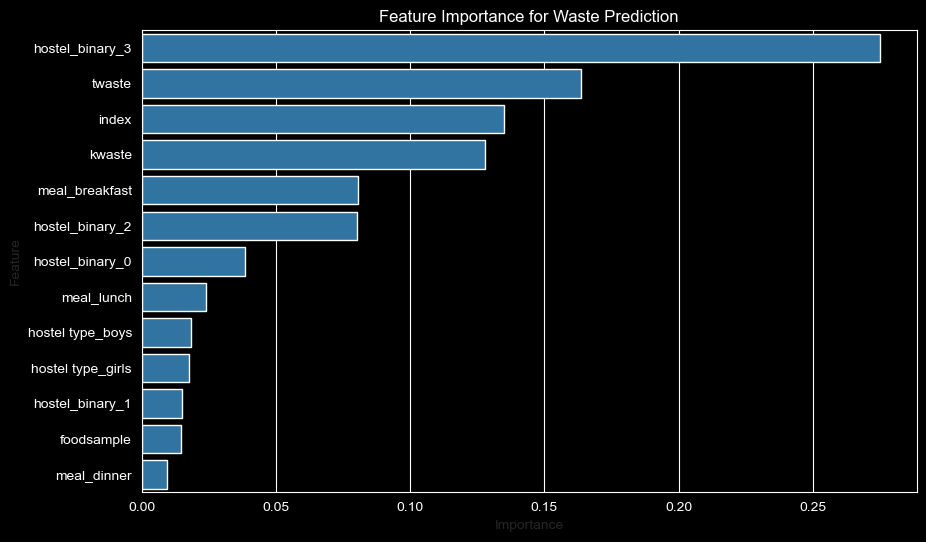

In [19]:
# Feature-based prediction with RandomForest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reset index to get original columns
dataset_ml = dataset.reset_index()

# Create features dataframe - avoid dropping 'date' since we need it
X = dataset_ml.drop(['date', 'pwaste'], axis=1)  # Remove date and target variable
y = dataset_ml['pwaste']  # Predict plate waste

# Check if there are any non-numeric columns left
non_numeric_cols = X.select_dtypes(exclude=['number']).columns
if len(non_numeric_cols) > 0:
    print(f"Non-numeric columns to handle: {non_numeric_cols}")
    # Convert any remaining categorical columns to numeric
    for col in non_numeric_cols:
        X[col] = pd.factorize(X[col])[0]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred, squared=False):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance for Waste Prediction', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.show()

Available columns: ['index', 'hostel type_boys', 'hostel type_girls', 'meal_breakfast', 'meal_dinner', 'meal_lunch', 'date', 'pwaste', 'twaste', 'foodsample', 'kwaste', 'hostel_binary_0', 'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3']
Using these features: ['meal_breakfast', 'meal_dinner', 'meal_lunch', 'twaste', 'foodsample', 'kwaste', 'hostel_binary_0', 'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3', 'hostel type_boys', 'hostel type_girls']
RMSE: 3.2260
R²: 0.6135


C:\Users\karan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


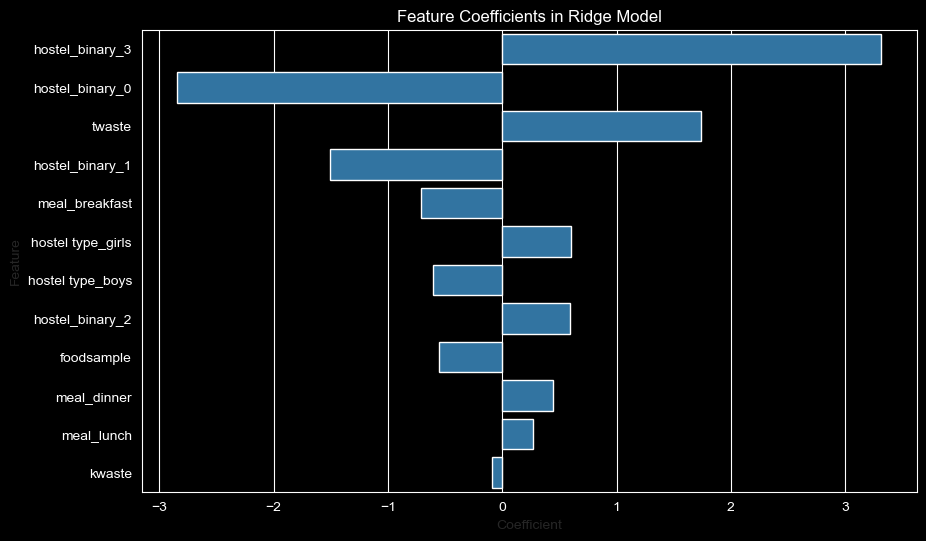

In [20]:
# Advanced prediction with Ridge Regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Reset index to get all columns
dataset_ridge = dataset.reset_index()

# Check actual column names to avoid KeyError
print("Available columns:", dataset_ridge.columns.tolist())

# Prepare data - use only columns that exist in the dataset
# First identify which features exist in the dataset
available_features = []
possible_features = ['meal_breakfast', 'meal_dinner', 'meal_lunch', 
                     'twaste', 'foodsample', 'kwaste', 
                     'hostel_binary_0', 'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3',
                     'hostel type_boys', 'hostel type_girls']

for feature in possible_features:
    if feature in dataset_ridge.columns:
        available_features.append(feature)

print("Using these features:", available_features)

X = dataset_ridge[available_features]
y = dataset_ridge['pwaste']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Ridge regression (good for multicollinearity)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

# Evaluate model
print(f"RMSE: {mean_squared_error(y_test, y_pred, squared=False):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

# Feature coefficients
coefficients = pd.DataFrame({
    'Feature': available_features,
    'Coefficient': ridge.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Feature Coefficients in Ridge Model', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.show()

All columns: ['index', 'hostel type_boys', 'hostel type_girls', 'meal_breakfast', 'meal_dinner', 'meal_lunch', 'date', 'pwaste', 'twaste', 'foodsample', 'kwaste', 'hostel_binary_0', 'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3', 'day_of_week']
Meal columns available: ['meal_breakfast', 'meal_dinner', 'meal_lunch']


<Figure size 1200x800 with 0 Axes>

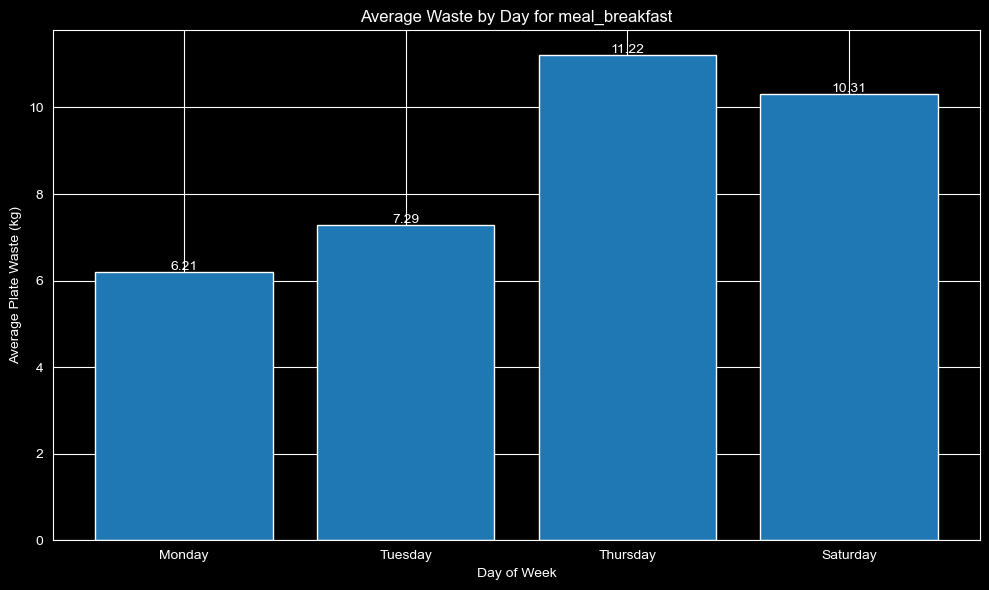

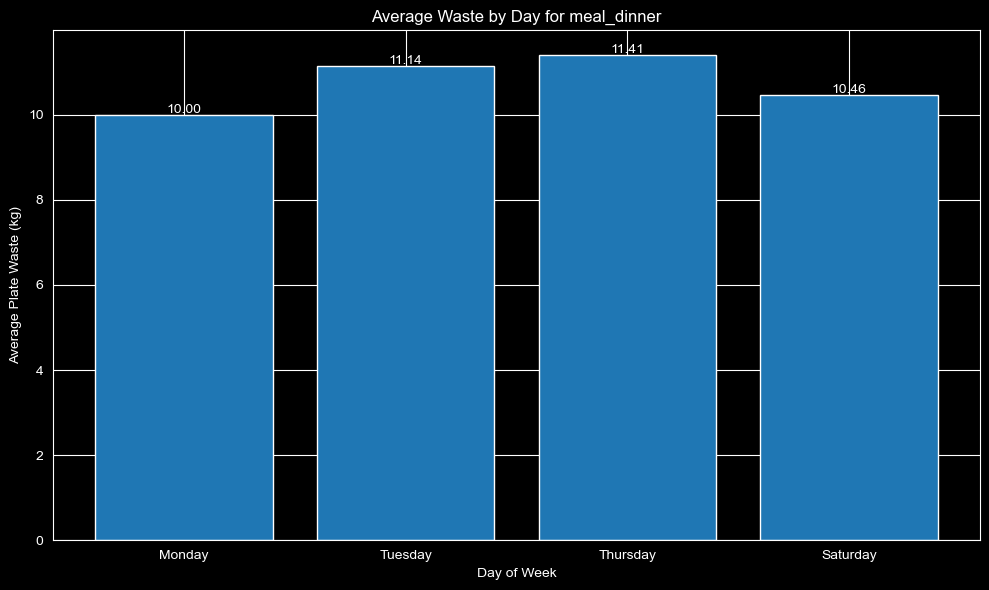

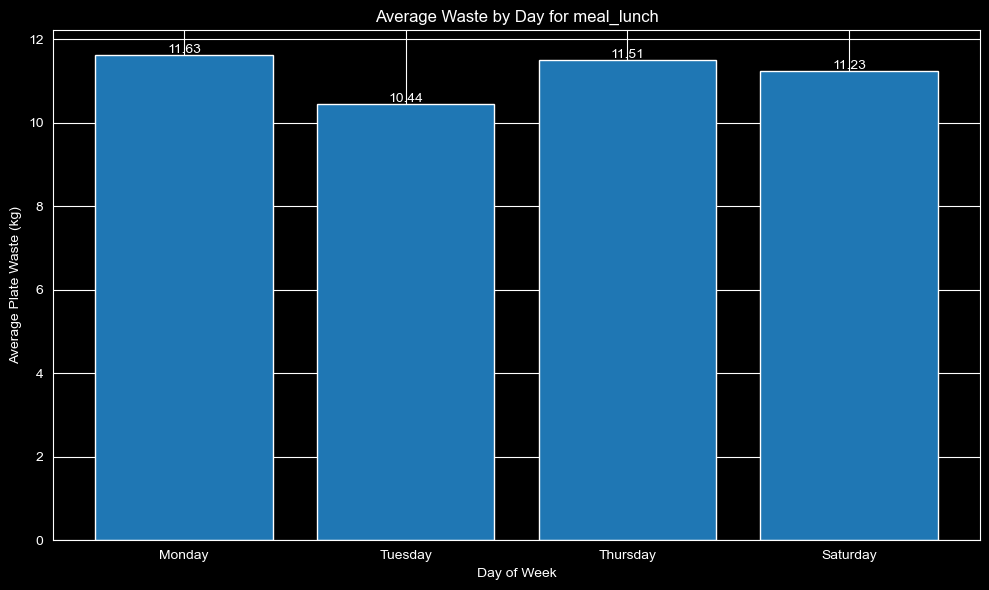

In [21]:
# Pattern detection by day of week and meal type - FIXED VERSION
# Reset index to get date as a column
dataset_patterns = dataset.reset_index()

# Create day of week from date
dataset_patterns['day_of_week'] = pd.to_datetime(dataset_patterns['date']).dt.day_name()

# Check for meal column in the dataset
print("All columns:", dataset_patterns.columns.tolist())

# Check if we need to encode meal column first
if 'meal' in dataset_patterns.columns:
    print("Found 'meal' column - encoding it first")
    # One-hot encode the meal column
    meal_dummies = pd.get_dummies(dataset_patterns['meal'], prefix='meal')
    dataset_patterns = pd.concat([dataset_patterns, meal_dummies], axis=1)
    
# Find meal columns after encoding
meal_columns = [col for col in dataset_patterns.columns if col.startswith('meal_')]
print("Meal columns available:", meal_columns)

if len(meal_columns) == 0:
    # If no meal columns, try using the meal column directly
    if 'meal' in dataset_patterns.columns:
        group_cols = ['day_of_week', 'meal']
        
        # Aggregate data
        patterns = dataset_patterns.groupby(group_cols)['pwaste'].mean().reset_index()
        
        # Create pivot table
        pivot = patterns.pivot(index='day_of_week', columns='meal', values='pwaste')
        
        # Make sure all values are numeric
        pivot = pivot.apply(pd.to_numeric, errors='coerce')
        
        # Plot heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(pivot, annot=True, cmap='viridis', fmt='.2f')
        plt.title('Average Waste by Day and Meal', color='white')
        plt.xticks(color='white') 
        plt.yticks(color='white')
        plt.show()
    else:
        print("No meal information found in the dataset")
else:
    # For each meal type column, create a separate visualization
    plt.figure(figsize=(12, 8))
    
    # Create a day of week to numeric mapping for consistent ordering
    day_order = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 
                 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
    
    # Create a simpler aggregation - one meal column at a time
    for meal_col in meal_columns:
        # Group by day and filter where meal is True (1)
        meal_data = dataset_patterns[dataset_patterns[meal_col] == 1]
        day_waste = meal_data.groupby('day_of_week')['pwaste'].mean().reset_index()
        
        # Sort by day of week - FIXED LINE BELOW
        if all(day in day_order for day in day_waste['day_of_week']):
            day_waste['day_order'] = day_waste['day_of_week'].map(day_order)
            day_waste = day_waste.sort_values('day_order')
            day_waste = day_waste.drop('day_order', axis=1)
        
        # Plot as bar chart instead of heatmap
        plt.figure(figsize=(10, 6))
        bars = plt.bar(day_waste['day_of_week'], day_waste['pwaste'])
        plt.title(f'Average Waste by Day for {meal_col}', color='white')
        plt.xlabel('Day of Week', color='white')
        plt.ylabel('Average Plate Waste (kg)', color='white')
        plt.xticks(color='white')
        plt.yticks(color='white')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                    f'{height:.2f}', ha='center', color='white')
            
        plt.tight_layout()
        plt.show()

         Date       Day       Meal Hostel  Predicted_Waste
0  2025-03-27  Thursday  breakfast   boys         6.274427
1  2025-03-27  Thursday  breakfast  girls         8.147090
2  2025-03-27  Thursday      lunch   boys         8.806089
3  2025-03-27  Thursday      lunch  girls        10.678752
4  2025-03-27  Thursday     dinner   boys         8.894645


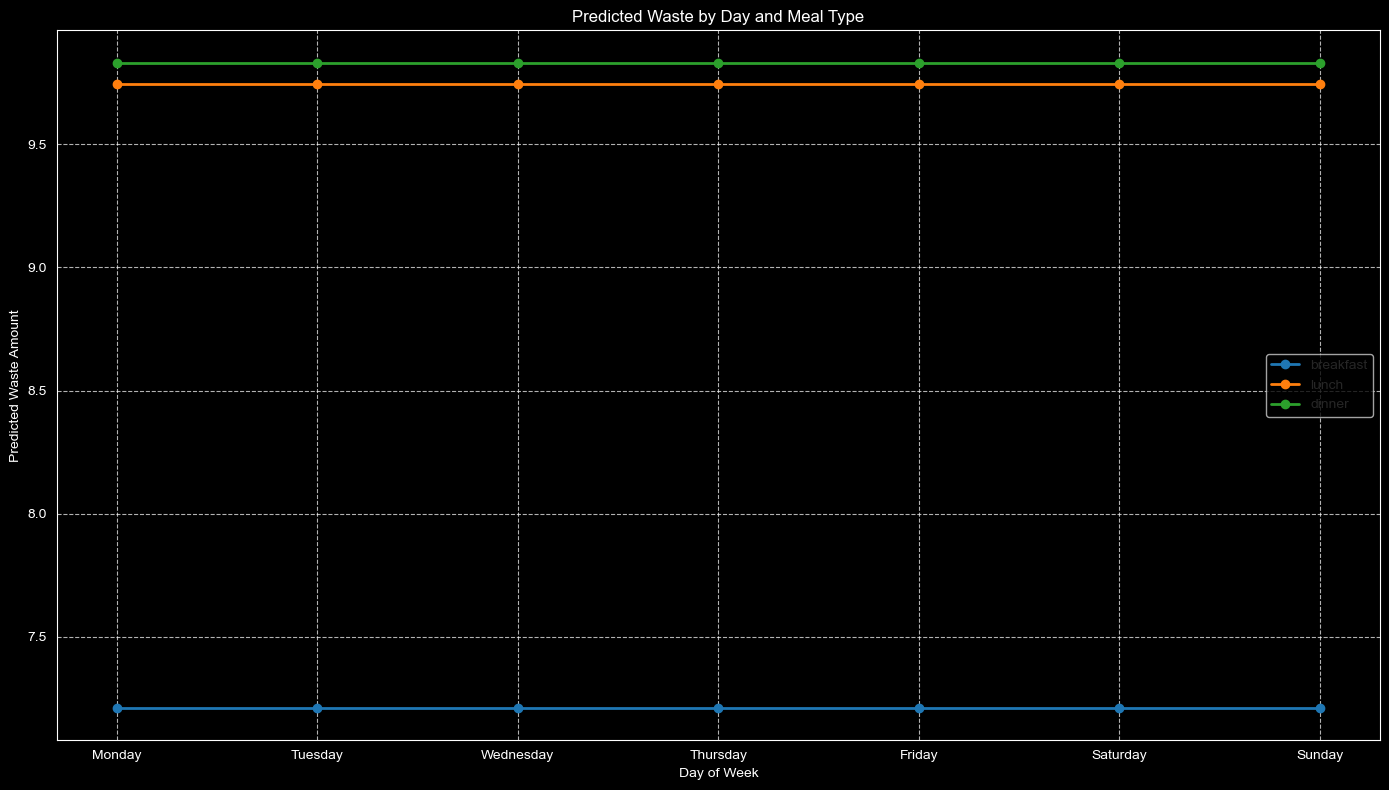

In [22]:
# FUTURE WASTE PREDICTION SYSTEM
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import datetime

# 1. Create a prediction pipeline with your model
prediction_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge_model', Ridge(alpha=1.0))
])

# 2. Train the pipeline on your full dataset
X = dataset_ridge[available_features]
y = dataset_ridge['pwaste']
prediction_pipeline.fit(X, y)

# 3. Create a function to predict waste for new scenarios
def predict_future_waste(meal_type, hostel_type, date, food_sample=None, kitchen_waste=None):
    """
    Predict plate waste for a future scenario
    
    Parameters:
    meal_type: str - 'breakfast', 'lunch', or 'dinner'
    hostel_type: str - 'boys' or 'girls'
    date: datetime - the date for prediction
    food_sample: float - optional food sample amount
    kitchen_waste: float - optional kitchen waste amount
    
    Returns:
    float - predicted waste amount
    """
    # Create a DataFrame with one row for the prediction
    future_data = pd.DataFrame(index=[0])
    
    # Fill meal type columns
    for meal in ['breakfast', 'lunch', 'dinner']:
        col_name = f'meal_{meal}'
        if col_name in available_features:
            future_data[col_name] = 1 if meal_type == meal else 0
    
    # Fill hostel type columns
    for htype in ['boys', 'girls']:
        col_name = f'hostel type_{htype}'
        if col_name in available_features:
            future_data[col_name] = 1 if hostel_type == htype else 0
    
    # Fill hostel binary columns if they exist
    # This depends on your specific encoding, adjust as needed
    hostel_binary_cols = [col for col in available_features if col.startswith('hostel_binary')]
    for col in hostel_binary_cols:
        future_data[col] = 0  # Default value, adjust based on your needs
    
    # Add other features if provided and available
    if 'foodsample' in available_features and food_sample is not None:
        future_data['foodsample'] = food_sample
    elif 'foodsample' in available_features:
        # Use median value from dataset if not provided
        future_data['foodsample'] = dataset_ridge['foodsample'].median()
        
    if 'twaste' in available_features and kitchen_waste is not None:
        future_data['twaste'] = kitchen_waste
    elif 'twaste' in available_features:
        # Use median value from dataset if not provided
        future_data['twaste'] = dataset_ridge['twaste'].median()
        
    if 'kwaste' in available_features and kitchen_waste is not None:
        future_data['kwaste'] = kitchen_waste
    elif 'kwaste' in available_features:
        # Use median value from dataset if not provided
        future_data['kwaste'] = dataset_ridge['kwaste'].median()
    
    # Make sure all required features are present
    for feature in available_features:
        if feature not in future_data.columns:
            future_data[feature] = 0
    
    # Reorder columns to match training data
    future_data = future_data[available_features]
    
    # Make prediction
    predicted_waste = prediction_pipeline.predict(future_data)[0]
    
    return predicted_waste

# 4. Example: Predict waste for next 7 days
today = datetime.datetime.now()
meal_types = ['breakfast', 'lunch', 'dinner']
hostel_types = ['boys', 'girls']

# Create dates for next 7 days
future_dates = [today + datetime.timedelta(days=i) for i in range(1, 8)]

# Create combinations of meal types and dates
predictions = []

for date in future_dates:
    date_str = date.strftime('%Y-%m-%d')
    day_name = date.strftime('%A')
    
    for meal in meal_types:
        for hostel in hostel_types:
            # Predict waste
            pred_waste = predict_future_waste(meal, hostel, date)
            
            predictions.append({
                'Date': date_str,
                'Day': day_name,
                'Meal': meal,
                'Hostel': hostel,
                'Predicted_Waste': pred_waste
            })

# Convert to DataFrame
predictions_df = pd.DataFrame(predictions)
print(predictions_df.head())

# 5. Visualize predictions
plt.figure(figsize=(14, 8))

# Plot predictions by meal type across days
for meal in meal_types:
    meal_data = predictions_df[predictions_df['Meal'] == meal]
    meal_avg = meal_data.groupby('Day')['Predicted_Waste'].mean()
    
    # Reorder days of week
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    meal_avg = meal_avg.reindex(day_order, fill_value=0)
    
    plt.plot(meal_avg.index, meal_avg.values, marker='o', linewidth=2, label=meal)

plt.title('Predicted Waste by Day and Meal Type', color='white')
plt.xlabel('Day of Week', color='white')
plt.ylabel('Predicted Waste Amount', color='white')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# 6. Interactive prediction tool (optional)
def get_prediction_for_scenario():
    """Simple function to get user input and make predictions"""
    print("\n--- Food Waste Prediction Tool ---")
    
    meal_type = input("Enter meal type (breakfast/lunch/dinner): ").lower()
    hostel_type = input("Enter hostel type (boys/girls): ").lower()
    
    # Optional inputs with defaults
    try:
        food_sample = float(input("Enter food sample amount (or press Enter for default): ") or 0)
    except ValueError:
        food_sample = None
        
    try:
        kitchen_waste = float(input("Enter kitchen waste amount (or press Enter for default): ") or 0)
    except ValueError:
        kitchen_waste = None
    
    # Make prediction
    prediction = predict_future_waste(meal_type, hostel_type, datetime.datetime.now(), 
                                     food_sample, kitchen_waste)
    
    print(f"\nPredicted plate waste: {prediction:.2f} units")
    return prediction

# Uncomment to use the interactive tool
# get_prediction_for_scenario()

In [23]:
# ENHANCED FOOD WASTE PREDICTION SYSTEM - FIXED VERSION
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator

# 1. Create a prediction pipeline with your Ridge model
prediction_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge_model', Ridge(alpha=1.0))
])

# 2. Train the pipeline on your complete dataset
X = dataset_ridge[available_features]
y = dataset_ridge['pwaste']
prediction_pipeline.fit(X, y)

# 3. Save the most important features for interpretation
coefficients = pd.DataFrame({
    'Feature': available_features,
    'Coefficient': prediction_pipeline.named_steps['ridge_model'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)
top_features = coefficients.head(3)['Feature'].tolist()

# 4. Enhanced prediction function with more flexibility - FIXED
def predict_future_waste(meal_type, hostel_type, date, food_sample=None, 
                         kwaste=None, twaste=None, day_of_week=None):
    """
    Predict plate waste for a future scenario with multiple options
    
    Parameters:
    meal_type: str - 'breakfast', 'lunch', or 'dinner'
    hostel_type: str - 'boys' or 'girls'
    date: datetime - the date for prediction (or None if using day_of_week)
    food_sample: float - optional food sample amount
    kwaste: float - optional kitchen waste amount
    twaste: float - optional total waste amount
    day_of_week: str - day of week if date not provided (e.g., 'Monday')
    
    Returns:
    dict - predicted waste amount and key factors
    """
    # Create a DataFrame with one row for the prediction
    future_data = pd.DataFrame(index=[0])
    
    # Determine day of week from date if not provided
    if day_of_week is None and date is not None:
        if isinstance(date, str):
            date = pd.to_datetime(date)
        try:
            # Try pandas method first
            day_of_week = date.day_name()
        except AttributeError:
            # Fallback to standard datetime method
            day_of_week = date.strftime('%A')
    
    # Fill meal type columns
    for meal in ['breakfast', 'lunch', 'dinner']:
        col_name = f'meal_{meal}'
        if col_name in available_features:
            future_data[col_name] = 1 if meal_type.lower() == meal else 0
    
    # Fill hostel type columns
    for htype in ['boys', 'girls']:
        col_name = f'hostel type_{htype}'
        if col_name in available_features:
            future_data[col_name] = 1 if hostel_type.lower() == htype else 0
    
    # Fill binary hostel columns - determine values based on historical pattern
    hostel_binary_cols = [col for col in available_features if col.startswith('hostel_binary')]
    
    # Default strategy: use most common pattern from dataset for selected hostel type
    if len(hostel_binary_cols) > 0:
        matching_data = dataset_ridge[dataset_ridge[f'hostel type_{hostel_type.lower()}'] == 1]
        if not matching_data.empty:
            for col in hostel_binary_cols:
                most_common = matching_data[col].mode()[0]
                future_data[col] = most_common
        else:
            # Fallback: set all to 0
            for col in hostel_binary_cols:
                future_data[col] = 0
    
    # Add other features if provided and available
    if 'foodsample' in available_features:
        if food_sample is not None:
            future_data['foodsample'] = food_sample
        else:
            future_data['foodsample'] = dataset_ridge['foodsample'].median()
            
    if 'twaste' in available_features:
        if twaste is not None:
            future_data['twaste'] = twaste
        else:
            # Use typical value for this meal type from historical data
            meal_col = f'meal_{meal_type.lower()}'
            if meal_col in dataset_ridge.columns:
                typical_value = dataset_ridge[dataset_ridge[meal_col] == 1]['twaste'].median()
                future_data['twaste'] = typical_value
            else:
                future_data['twaste'] = dataset_ridge['twaste'].median()
            
    if 'kwaste' in available_features:
        if kwaste is not None:
            future_data['kwaste'] = kwaste
        else:
            # Use typical value for this meal type from historical data
            meal_col = f'meal_{meal_type.lower()}'
            if meal_col in dataset_ridge.columns:
                typical_value = dataset_ridge[dataset_ridge[meal_col] == 1]['kwaste'].median()
                future_data['kwaste'] = typical_value
            else:
                future_data['kwaste'] = dataset_ridge['kwaste'].median()
    
    # Make sure all required features are present
    for feature in available_features:
        if feature not in future_data.columns:
            future_data[feature] = 0
    
    # Reorder columns to match training data
    future_data = future_data[available_features]
    
    # Make prediction
    predicted_waste = prediction_pipeline.predict(future_data)[0]
    
    # Prepare impact factors (which features contributed most)
    impact_factors = {}
    for feature in top_features:
        if feature in future_data.columns:
            impact_factors[feature] = future_data[feature].values[0]
    
    return {
        'predicted_waste': predicted_waste,
        'meal_type': meal_type,
        'hostel_type': hostel_type,
        'day': day_of_week,
        'impact_factors': impact_factors
    }

# 5. Create a function to generate a weekly prediction chart - FIXED
def predict_week_ahead(start_date=None):
    """Generate predictions for the next 7 days starting from a given date"""
    
    if start_date is None:
        start_date = datetime.datetime.now()
    elif isinstance(start_date, str):
        start_date = pd.to_datetime(start_date)
        
    # Create dates for next 7 days
    future_dates = [start_date + datetime.timedelta(days=i) for i in range(7)]
    meal_types = ['breakfast', 'lunch', 'dinner']
    hostel_types = ['boys', 'girls']
    
    # Create combinations of meal types and dates
    predictions = []
    
    for date in future_dates:
        date_str = date.strftime('%Y-%m-%d')
        day_name = date.strftime('%A')  # Using standard datetime method instead of day_name()
        
        for meal in meal_types:
            for hostel in hostel_types:
                # Predict waste with day_of_week parameter
                result = predict_future_waste(meal, hostel, None, day_of_week=day_name)
                
                predictions.append({
                    'Date': date_str,
                    'Day': day_name,
                    'Meal': meal,
                    'Hostel': hostel,
                    'Predicted_Waste': result['predicted_waste']
                })
    
    # Convert to DataFrame
    predictions_df = pd.DataFrame(predictions)
    
    # Visualize predictions
    plt.figure(figsize=(14, 8))
    
    # Set up a dark grid style
    sns.set_style("darkgrid", {
        'axes.facecolor': 'black',
        'figure.facecolor': 'black',
        'grid.color': 'white'
    })
    
    # Plot predictions by meal type across days
    for meal in meal_types:
        meal_data = predictions_df[predictions_df['Meal'] == meal]
        meal_avg = meal_data.groupby('Day')['Predicted_Waste'].mean()
        
        # Reorder days of week
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        # Ensure all days are in the index
        for day in day_order:
            if day not in meal_avg.index:
                meal_avg[day] = 0
        
        meal_avg = meal_avg.reindex(day_order)
        
        plt.plot(meal_avg.index, meal_avg.values, marker='o', linewidth=3, label=meal.capitalize())
    
    # Find the highest predicted waste for highlighting
    max_meal = predictions_df.groupby(['Day', 'Meal'])['Predicted_Waste'].mean().reset_index()
    max_idx = max_meal['Predicted_Waste'].idxmax()
    max_day = max_meal.loc[max_idx, 'Day']
    max_meal_type = max_meal.loc[max_idx, 'Meal']
    max_value = max_meal.loc[max_idx, 'Predicted_Waste']
    
    # Add annotation for highest waste
    plt.annotate(f"Highest predicted waste:\n{max_meal_type.capitalize()}, {max_day}\n{max_value:.2f} kg",
                xy=(day_order.index(max_day), max_value),
                xytext=(day_order.index(max_day)-1, max_value+0.3),
                arrowprops=dict(facecolor='red', shrink=0.05, width=2),
                color='white', fontsize=11, fontweight='bold')
    
    plt.title('Predicted Food Waste by Day and Meal Type', color='white', fontsize=16)
    plt.xlabel('Day of Week', color='white', fontsize=12)
    plt.ylabel('Predicted Plate Waste (kg)', color='white', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title="Meal Type", fontsize=11, title_fontsize=12)
    plt.xticks(color='white', fontsize=10)
    plt.yticks(color='white', fontsize=10)
    
    # Set y-axis to start from 0
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Add a horizontal line for overall average
    overall_avg = predictions_df['Predicted_Waste'].mean()
    plt.axhline(y=overall_avg, color='r', linestyle='--', alpha=0.7)
    plt.text(0, overall_avg*1.05, f'Overall Average: {overall_avg:.2f} kg', 
             color='white', fontsize=10)
    
    # Set up legend with white text
    legend = plt.legend()
    plt.setp(legend.get_texts(), color='white')
    plt.setp(legend.get_title(), color='white')
    
    plt.tight_layout()
    plt.show()
    
    return predictions_df

# 6. Create a function to generate daily waste breakdown - FIXED
def daily_meal_prediction(date_or_day):
    """Generate detailed predictions for a specific day"""
    
    # If given a date string, convert it; if given a day name, use it directly
    if isinstance(date_or_day, str) and date_or_day in ['Monday', 'Tuesday', 'Wednesday', 
                                                     'Thursday', 'Friday', 'Saturday', 'Sunday']:
        day_of_week = date_or_day
        date = None
    else:
        if isinstance(date_or_day, str):
            date = pd.to_datetime(date_or_day)
        else:
            date = date_or_day
        try:
            day_of_week = date.day_name()
        except AttributeError:
            day_of_week = date.strftime('%A')
    
    meal_types = ['breakfast', 'lunch', 'dinner']
    hostel_types = ['boys', 'girls']
    
    # Create all combinations
    results = []
    
    for meal in meal_types:
        for hostel in hostel_types:
            prediction = predict_future_waste(meal, hostel, None, day_of_week=day_of_week)
            results.append({
                'Meal': meal.capitalize(),
                'Hostel': hostel.capitalize(),
                'Predicted_Waste': prediction['predicted_waste'],
                'Impact_Factors': prediction['impact_factors']
            })
    
    # Rest of function stays the same...
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Create visualizations
    plt.figure(figsize=(14, 9))
    
    # Create a grouped bar chart
    ax = plt.subplot(111)
    
    # Prepare data for grouped bar chart
    pivoted = results_df.pivot(index='Meal', columns='Hostel', values='Predicted_Waste')
    
    # Plot grouped bars
    bar_width = 0.35
    index = np.arange(len(meal_types))
    
    # Plot each group
    rects1 = ax.bar(index - bar_width/2, pivoted['Boys'], bar_width, 
                   label='Boys Hostel', color='skyblue')
    rects2 = ax.bar(index + bar_width/2, pivoted['Girls'], bar_width,
                   label='Girls Hostel', color='lightcoral')
    
    # Add labels and title
    plt.title(f'Predicted Food Waste for {day_of_week}', color='white', fontsize=16)
    plt.xlabel('Meal Type', color='white', fontsize=12)
    plt.ylabel('Predicted Plate Waste (kg)', color='white', fontsize=12)
    plt.xticks(index, meal_types, color='white', fontsize=10)
    plt.yticks(color='white', fontsize=10)
    
    # Add value labels on top of bars
    def add_labels(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                       xy=(rect.get_x() + rect.get_width()/2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', color='white')
    
    add_labels(rects1)
    add_labels(rects2)
    
    # Add legend
    legend = plt.legend(loc='best')
    plt.setp(legend.get_texts(), color='white')
    
    # Find and highlight the meal with highest waste
    max_row_idx = results_df['Predicted_Waste'].idxmax()
    max_meal = results_df.loc[max_row_idx, 'Meal']
    max_hostel = results_df.loc[max_row_idx, 'Hostel']
    max_waste = results_df.loc[max_row_idx, 'Predicted_Waste']
    
    # Add recommendation text box
    recommendation = (f"Highest waste prediction: {max_waste:.2f} kg during {max_meal} at {max_hostel} hostel\n\n"
                      f"Top contributing factors based on model coefficients:\n")
                      
    for i, (feature, coef) in enumerate(coefficients.head(3).values):
        recommendation += f"{i+1}. {feature}: {coef:.4f}\n"
    
    recommendation += "\nRecommendation: Focus waste reduction efforts on this meal combination."
    
    props = dict(boxstyle='round', facecolor='black', alpha=0.7, edgecolor='white')
    plt.figtext(0.15, 0.02, recommendation, fontsize=11, color='white',
               bbox=props, horizontalalignment='left')
    
    plt.tight_layout(rect=[0, 0.15, 1, 0.95])  # Adjust layout to make room for text box
    plt.show()
    
    return results_df

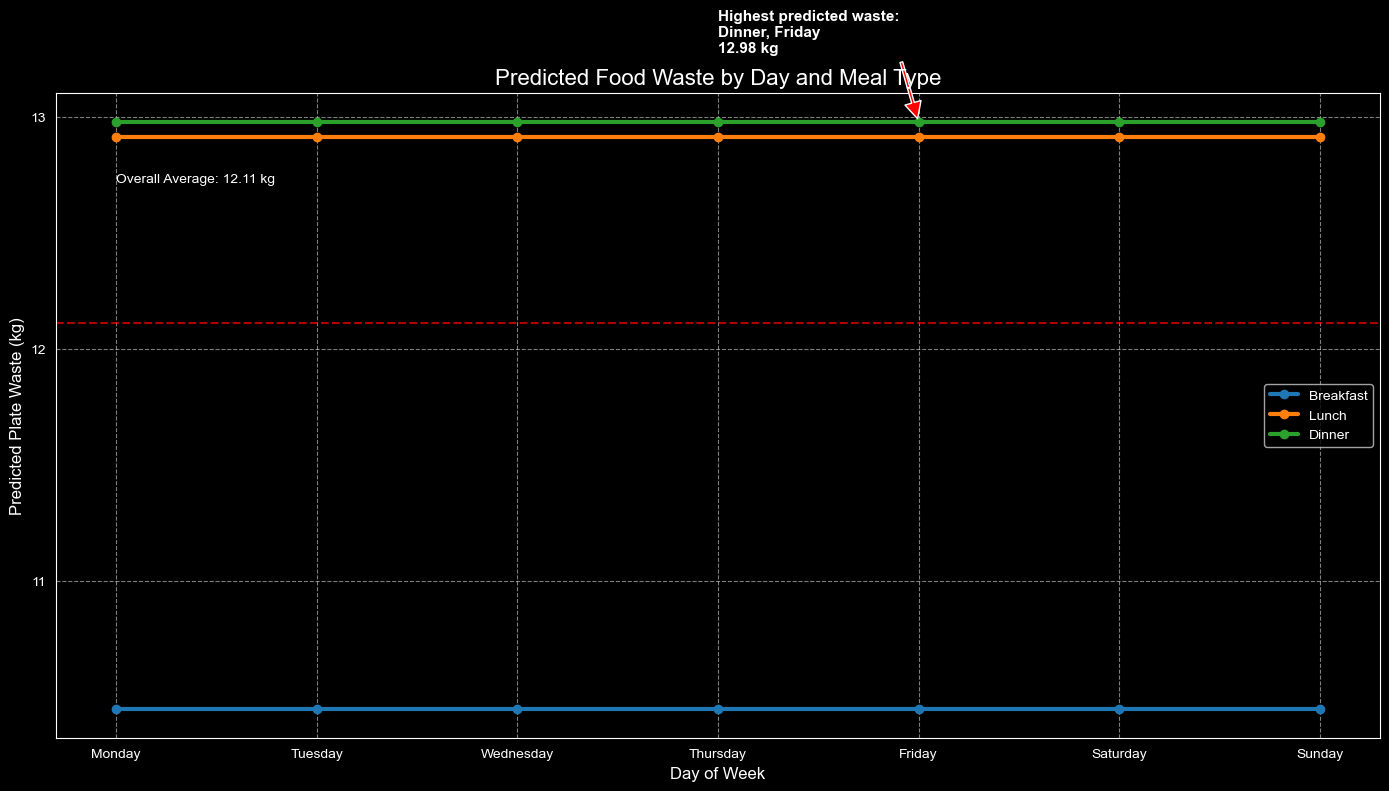

,Date,Day,Meal,Hostel,Predicted_Waste
0,2025-03-26,Wednesday,breakfast,boys,12.669302
1,2025-03-26,Wednesday,breakfast,girls,8.223897
2,2025-03-26,Wednesday,lunch,boys,15.135684
3,2025-03-26,Wednesday,lunch,girls,10.690279
4,2025-03-26,Wednesday,dinner,boys,15.199471
5,2025-03-26,Wednesday,dinner,girls,10.754066
6,2025-03-27,Thursday,breakfast,boys,12.669302
7,2025-03-27,Thursday,breakfast,girls,8.223897
8,2025-03-27,Thursday,lunch,boys,15.135684
9,2025-03-27,Thursday,lunch,girls,10.690279


In [24]:
predict_week_ahead()

Hostel Ranking by Total Waste Generation:
   hostel_id total_waste
7          7      416.51
3          3      398.32
5          5   382.82031
0          0      377.11
1          1      365.71
4          4      252.51
9          9       248.9
6          6    232.5505
2          2     193.031
8          8       191.1


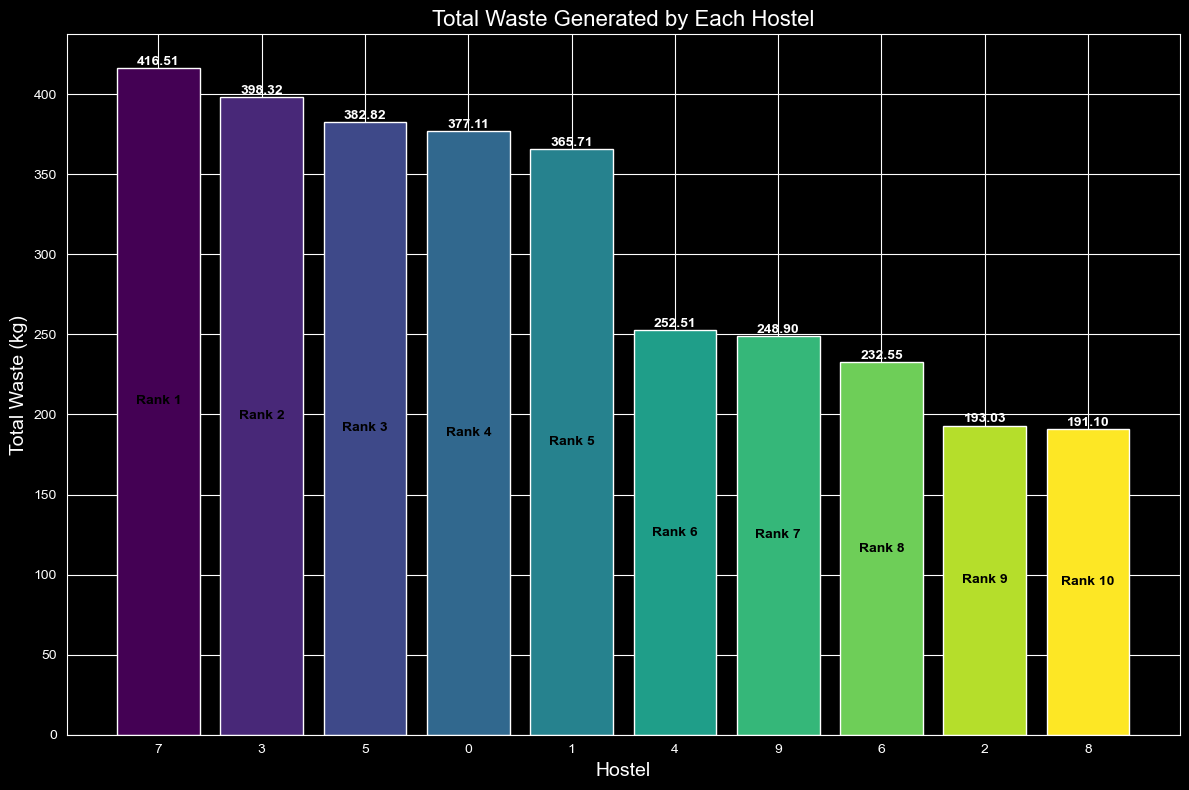

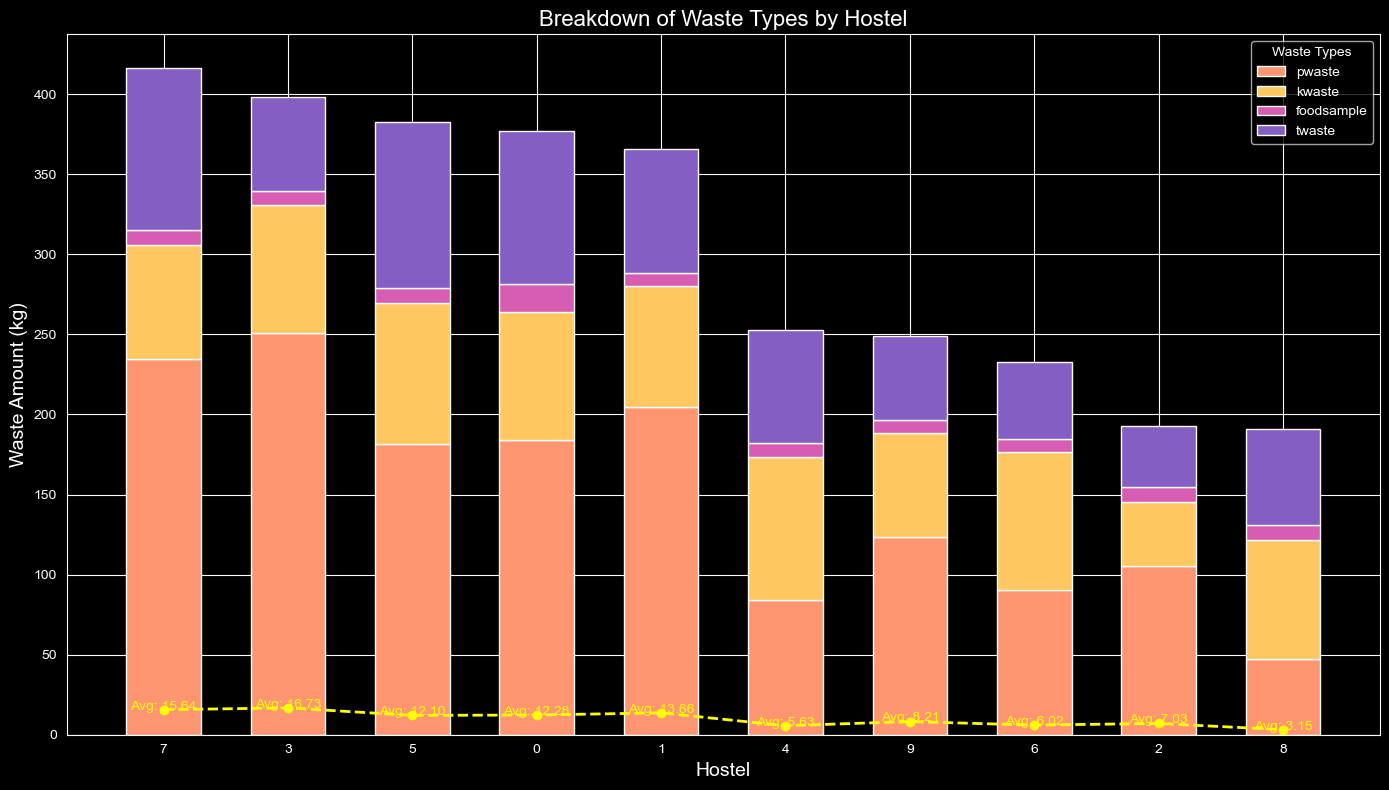

TypeError: unsupported operand type(s) for +: 'dict' and 'dict'

In [25]:
# HOSTEL WASTE RANKING ANALYSIS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# First, reset index if needed to get all columns
dataset_ranking = dataset.reset_index()

# Check if we have the original hostel identifier before binary encoding
if 'hostel' in dataset_ranking.columns:
    # Use original hostel identifiers if available
    hostel_column = 'hostel'
    hostels = dataset_ranking[hostel_column].unique()
    
    # Get total waste by hostel
    hostel_waste = dataset_ranking.groupby(hostel_column).agg({
        'pwaste': 'sum',
        'kwaste': 'sum',
        'foodsample': 'sum',
        'twaste': 'sum'
    }).reset_index()
    
    # Calculate total overall waste for each hostel
    hostel_waste['total_waste'] = hostel_waste['pwaste'] + hostel_waste['kwaste'] + \
                                 hostel_waste['foodsample'] + hostel_waste['twaste']
    
    # Sort by total waste (descending)
    hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)
    
else:
    # Since hostel column was binary encoded, we need to reconstruct hostel identifiers
    # First, let's identify the binary columns
    binary_cols = [col for col in dataset_ranking.columns if col.startswith('hostel_binary')]
    
    # Create a function to decode the binary encoding back to hostel IDs
    def decode_hostel_id(row):
        binary_string = ''
        for col in sorted(binary_cols):  # Sort to ensure correct order
            binary_string += str(int(row[col]))
        return int(binary_string, 2)  # Convert binary string to integer
    
    # Apply the decoding function to create a hostel ID column
    dataset_ranking['hostel_id'] = dataset_ranking.apply(decode_hostel_id, axis=1)
    
    # Get total waste by reconstructed hostel ID
    hostel_waste = dataset_ranking.groupby('hostel_id').agg({
        'pwaste': 'sum',
        'kwaste': 'sum',
        'foodsample': 'sum',
        'twaste': 'sum'
    }).reset_index()
    
    # Calculate total overall waste for each hostel
    hostel_waste['total_waste'] = hostel_waste['pwaste'] + hostel_waste['kwaste'] + \
                                 hostel_waste['foodsample'] + hostel_waste['twaste']
    
    # Sort by total waste (descending)
    hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)
    hostel_column = 'hostel_id'

# Display the ranked results
print("Hostel Ranking by Total Waste Generation:")
print(hostel_waste[[hostel_column, 'total_waste']])

# Visualization for hostel rankings
plt.figure(figsize=(12, 8))
sns.set_style("darkgrid", {
    'axes.facecolor': 'black',
    'figure.facecolor': 'black',
    'grid.color': 'white'
})

# Create a bar chart showing total waste by hostel
bars = plt.bar(hostel_waste[hostel_column].astype(str), hostel_waste['total_waste'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(hostel_waste))))

# Add waste amount labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f}',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add labels and title
plt.title('Total Waste Generated by Each Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Total Waste (kg)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

# Add ranking numbers above bars
for i, (bar, waste) in enumerate(zip(bars, hostel_waste['total_waste'])):
    plt.text(bar.get_x() + bar.get_width()/2., waste/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

# BREAKDOWN ANALYSIS - Waste by hostel and type

# Create a stacked bar chart showing breakdown of waste types by hostel
plt.figure(figsize=(14, 8))

# Set up the bar positions
x = np.arange(len(hostel_waste))
width = 0.6

# Create the stacked bars
bottom_data = np.zeros(len(hostel_waste))

for waste_type, color in zip(['pwaste', 'kwaste', 'foodsample', 'twaste'], 
                            ['#FF9671', '#FFC75F', '#D65DB1', '#845EC2']):
    plt.bar(x, hostel_waste[waste_type], width, bottom=bottom_data, 
           label=waste_type, color=color)
    bottom_data += hostel_waste[waste_type]

# Customize the chart
plt.title('Breakdown of Waste Types by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Waste Amount (kg)', color='white', fontsize=14)
plt.xticks(x, hostel_waste[hostel_column].astype(str), color='white')
plt.yticks(color='white')

# Add a legend with white text
legend = plt.legend(title='Waste Types', loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

# Add expected values - average waste per meal
avg_waste_per_meal = dataset_ranking.groupby(hostel_column)['pwaste'].mean()
hostel_order = hostel_waste[hostel_column].tolist()
avg_values = [avg_waste_per_meal[h] if h in avg_waste_per_meal else 0 for h in hostel_order]

# Plot average line
avg_points = []
for i, avg in enumerate(avg_values):
    avg_points.append((i, avg))
    plt.text(i, avg + 0.1, f'Avg: {avg:.2f}', color='yellow', ha='center')

avg_x, avg_y = zip(*avg_points)
plt.plot(avg_x, avg_y, 'o--', color='yellow', linewidth=2, label='Avg waste/meal')

plt.tight_layout()
plt.show()

# PREDICTION: Expected future waste by hostel
# Use the prediction model we built earlier to forecast waste by hostel

# For each hostel, predict next 7 days of waste
meal_types = ['breakfast', 'lunch', 'dinner']
future_dates = [pd.Timestamp.now() + pd.Timedelta(days=i) for i in range(1, 8)]

# Create a dictionary to store predictions
hostel_predictions = {}

# For each hostel, predict waste for each meal type
for hostel_id in hostel_waste[hostel_column]:
    # Determine hostel type (boys/girls)
    if 'hostel type_boys' in dataset_ranking.columns and 'hostel type_girls' in dataset_ranking.columns:
        # Find which hostel type this hostel belongs to
        hostel_rows = dataset_ranking[dataset_ranking[hostel_column] == hostel_id]
        is_boys = hostel_rows['hostel type_boys'].iloc[0] if not hostel_rows.empty else 0
        hostel_type = 'boys' if is_boys else 'girls'
    else:
        # Default to 'boys' if we can't determine
        hostel_type = 'boys'
    
    # Collect predictions for all meals
    predictions = []
    for date in future_dates:
        for meal in meal_types:
            # Call our prediction function
            pred = predict_future_waste(meal, hostel_type, date)
            predictions.append(pred)
    
    # Store the average predicted waste for this hostel
    hostel_predictions[hostel_id] = np.mean(predictions)

# Convert to dataframe for visualization
predictions_df = pd.DataFrame({
    'Hostel': hostel_predictions.keys(),
    'Expected_Waste': hostel_predictions.values()
}).sort_values('Expected_Waste', ascending=False)

# Create a horizontal bar chart showing expected waste ranking
plt.figure(figsize=(12, 8))

# Create horizontal bars with gradient colors based on waste amount
colors = plt.cm.plasma(np.linspace(0, 0.8, len(predictions_df)))
bars = plt.barh(predictions_df['Hostel'].astype(str), predictions_df['Expected_Waste'], color=colors)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.1, i, f'{width:.2f} kg/day', 
            ha='left', va='center', color='white', fontweight='bold')

# Add rank numbers inside bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width/2, i, f'Rank {i+1}', 
            ha='center', va='center', color='black', fontweight='bold')

# Customize the chart
plt.title('Expected Future Waste Ranking by Hostel', color='white', fontsize=16)
plt.xlabel('Expected Daily Waste (kg)', color='white', fontsize=14)
plt.ylabel('Hostel', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()

# WASTE REDUCTION RECOMMENDATIONS
# For each hostel, provide suggestions based on their waste patterns

hostel_recommendations = {}

for idx, row in hostel_waste.iterrows():
    hostel_id = row[hostel_column]
    total = row['total_waste']
    plate = row['pwaste']
    kitchen = row['kwaste']
    
    # Calculate percentages
    plate_pct = 100 * plate / total if total > 0 else 0
    kitchen_pct = 100 * kitchen / total if total > 0 else 0
    
    recommendation = f"Hostel {hostel_id} Recommendations:\n"
    
    if plate_pct > 60:
        recommendation += "• HIGH PLATE WASTE: Consider reducing portion sizes\n"
        recommendation += "• Monitor student food preferences and adjust menu\n"
    elif plate_pct > 40:
        recommendation += "• MEDIUM PLATE WASTE: Review serving practices\n"
    
    if kitchen_pct > 40:
        recommendation += "• HIGH KITCHEN WASTE: Improve food preparation methods\n"
        recommendation += "• Enhance inventory management to reduce spoilage\n"
    
    # Add general recommendation based on ranking
    rank = hostel_waste[hostel_column].tolist().index(hostel_id) + 1
    if rank == 1:
        recommendation += f"• HIGHEST WASTE GENERATOR: Needs immediate attention\n"
    elif rank <= 3:
        recommendation += f"• TOP 3 WASTE GENERATOR: Requires waste reduction plan\n"
    
    hostel_recommendations[hostel_id] = recommendation

print("\nWaste Reduction Recommendations:")
for hostel_id, recommendation in hostel_recommendations.items():
    print(f"\n{recommendation}")

Hostel Ranking by Total Waste Generation:
   hostel_id hostel_name total_waste
7          7    Hostel A      416.51
3          3    Hostel B      398.32
5          5    Hostel C   382.82031
0          0    Hostel D      377.11
1          1    Hostel E      365.71
4          4    Hostel F      252.51
9          9    Hostel G       248.9
6          6    Hostel H    232.5505
2          2    Hostel I     193.031
8          8    Hostel J       191.1


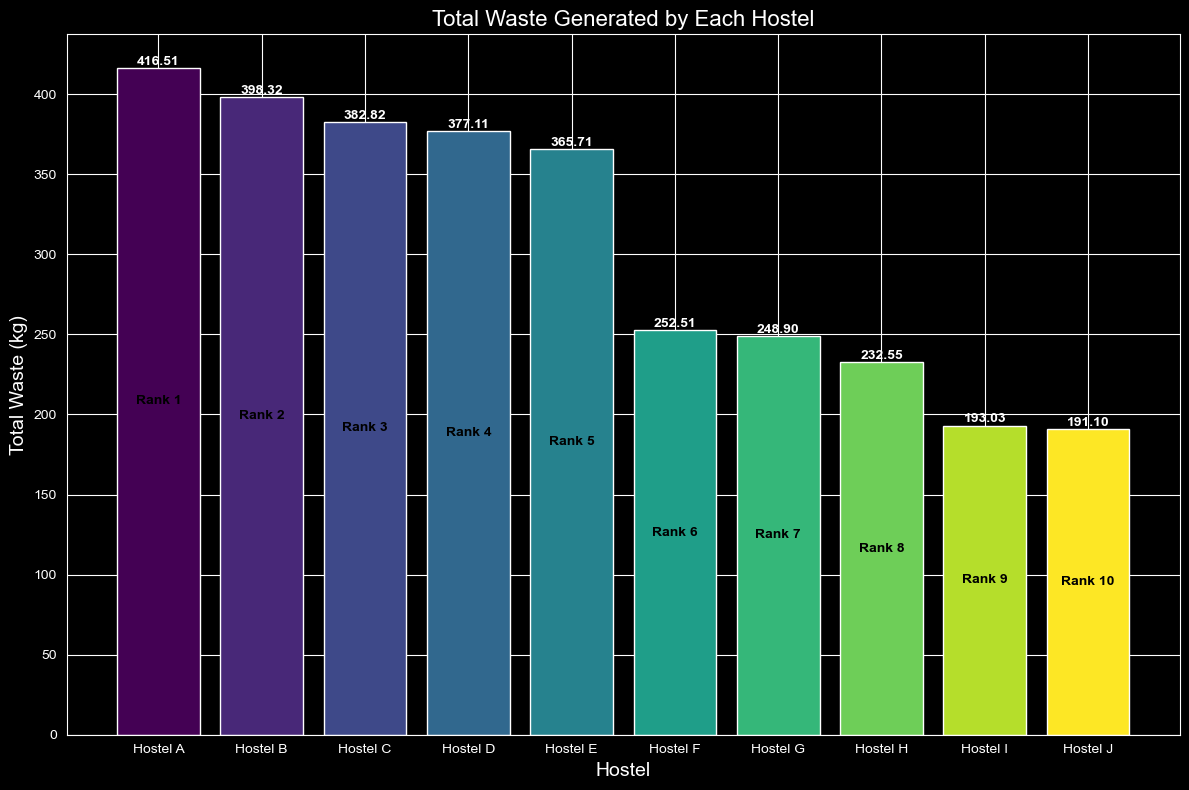

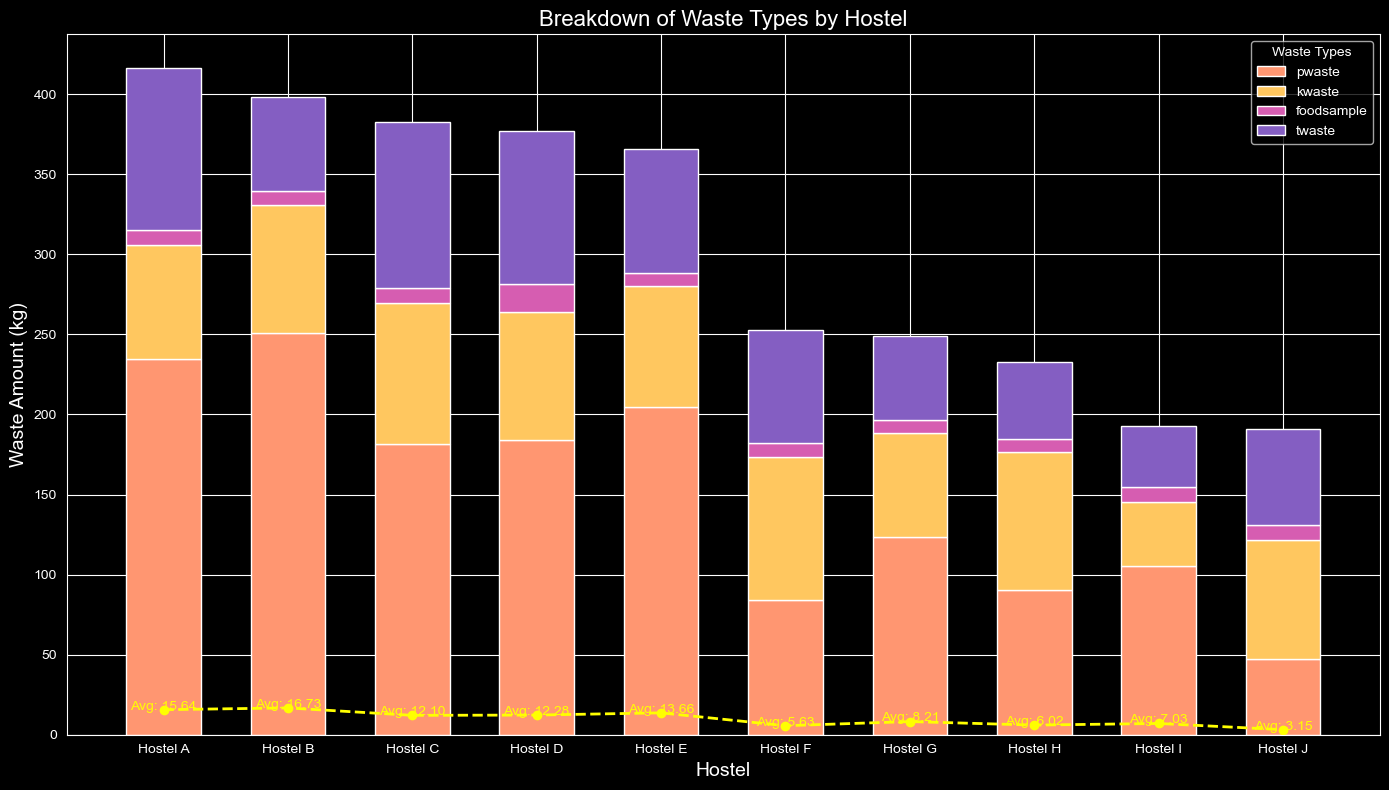

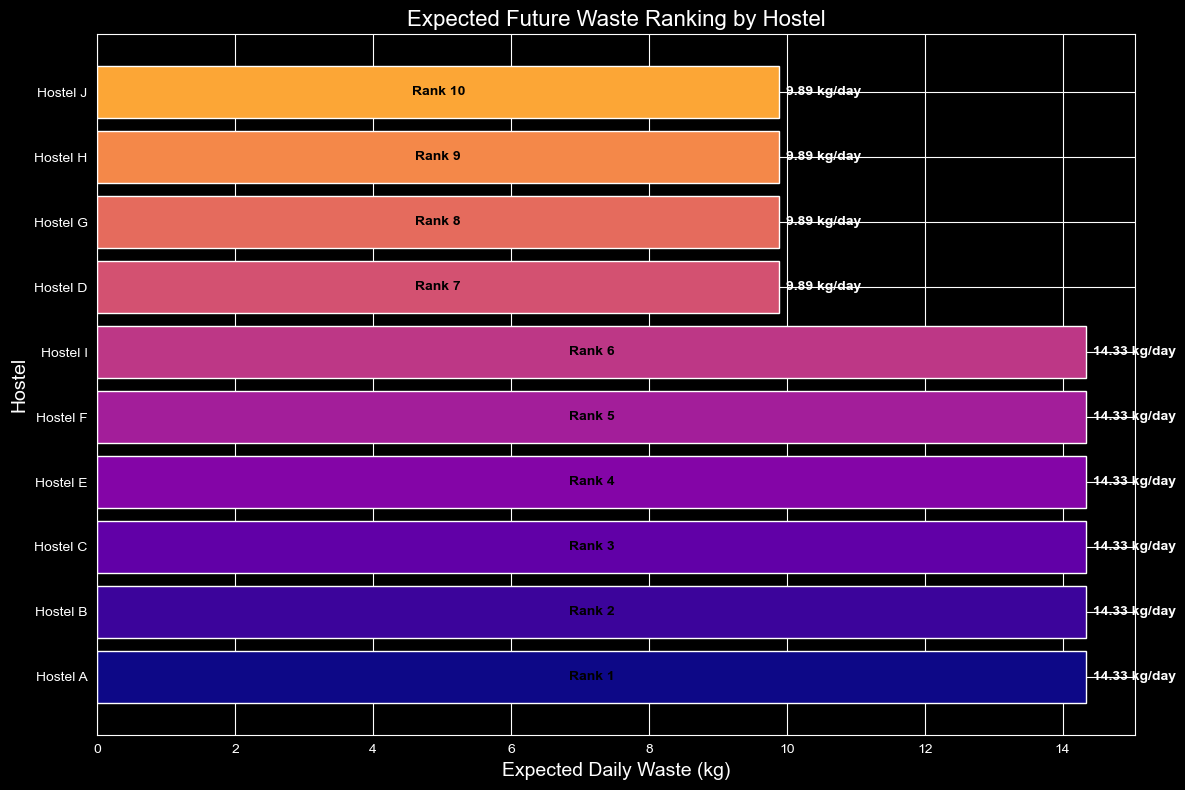


Waste Reduction Recommendations:

Hostel A Recommendations:
• MEDIUM PLATE WASTE: Review serving practices
• HIGHEST WASTE GENERATOR: Needs immediate attention


Hostel B Recommendations:
• HIGH PLATE WASTE: Consider reducing portion sizes
• Monitor student food preferences and adjust menu
• TOP 3 WASTE GENERATOR: Requires waste reduction plan


Hostel C Recommendations:
• MEDIUM PLATE WASTE: Review serving practices
• TOP 3 WASTE GENERATOR: Requires waste reduction plan


Hostel D Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel E Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel F Recommendations:


Hostel G Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel H Recommendations:


Hostel I Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel J Recommendations:



In [26]:
# CORRECTED HOSTEL WASTE RANKING ANALYSIS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# First, reset index if needed to get all columns
dataset_ranking = dataset.reset_index()

# Check if we have the original hostel identifier before binary encoding
if 'hostel' in dataset_ranking.columns:
    # Use original hostel identifiers if available
    hostel_column = 'hostel'
    hostels = dataset_ranking[hostel_column].unique()
    
    # Get total waste by hostel
    hostel_waste = dataset_ranking.groupby(hostel_column).agg({
        'pwaste': 'sum',
        'kwaste': 'sum',
        'foodsample': 'sum',
        'twaste': 'sum'
    }).reset_index()
    
    # Calculate total overall waste for each hostel
    hostel_waste['total_waste'] = hostel_waste['pwaste'] + hostel_waste['kwaste'] + \
                                 hostel_waste['foodsample'] + hostel_waste['twaste']
    
    # Sort by total waste (descending)
    hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)
    
else:
    # Since hostel column was binary encoded, we need to reconstruct hostel identifiers
    # First, let's identify the binary columns
    binary_cols = [col for col in dataset_ranking.columns if col.startswith('hostel_binary')]
    
    # Create a function to decode the binary encoding back to hostel IDs
    def decode_hostel_id(row):
        binary_string = ''
        for col in sorted(binary_cols):  # Sort to ensure correct order
            binary_string += str(int(row[col]))
        return int(binary_string, 2)  # Convert binary string to integer
    
    # Apply the decoding function to create a hostel ID column
    dataset_ranking['hostel_id'] = dataset_ranking.apply(decode_hostel_id, axis=1)
    
    # Get total waste by reconstructed hostel ID
    hostel_waste = dataset_ranking.groupby('hostel_id').agg({
        'pwaste': 'sum',
        'kwaste': 'sum',
        'foodsample': 'sum',
        'twaste': 'sum'
    }).reset_index()
    
    # Calculate total overall waste for each hostel
    hostel_waste['total_waste'] = hostel_waste['pwaste'] + hostel_waste['kwaste'] + \
                                 hostel_waste['foodsample'] + hostel_waste['twaste']
    
    # Sort by total waste (descending)
    hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)
    hostel_column = 'hostel_id'

# Create a dictionary to map hostel IDs to meaningful names
# Customize this based on your actual hostel names
hostel_names = {}
for i, hostel_id in enumerate(hostel_waste[hostel_column]):
    if isinstance(hostel_id, (int, np.integer)):
        hostel_names[hostel_id] = f"Hostel {chr(65 + i)}"  # A, B, C, etc.
    else:
        hostel_names[hostel_id] = str(hostel_id)

# Add hostel names to the waste dataframe
hostel_waste['hostel_name'] = hostel_waste[hostel_column].map(hostel_names)

# Display the ranked results
print("Hostel Ranking by Total Waste Generation:")
print(hostel_waste[[hostel_column, 'hostel_name', 'total_waste']])

# Visualization for hostel rankings
plt.figure(figsize=(12, 8))
sns.set_style("darkgrid", {
    'axes.facecolor': 'black',
    'figure.facecolor': 'black',
    'grid.color': 'white'
})

# Create a bar chart showing total waste by hostel, using hostel names
bars = plt.bar(hostel_waste['hostel_name'], hostel_waste['total_waste'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(hostel_waste))))

# Add waste amount labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f}',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add labels and title
plt.title('Total Waste Generated by Each Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Total Waste (kg)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

# Add ranking numbers above bars
for i, (bar, waste) in enumerate(zip(bars, hostel_waste['total_waste'])):
    plt.text(bar.get_x() + bar.get_width()/2., waste/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

# BREAKDOWN ANALYSIS - Waste by hostel and type

# Create a stacked bar chart showing breakdown of waste types by hostel
plt.figure(figsize=(14, 8))

# Set up the bar positions
x = np.arange(len(hostel_waste))
width = 0.6

# Create the stacked bars
bottom_data = np.zeros(len(hostel_waste))

for waste_type, color in zip(['pwaste', 'kwaste', 'foodsample', 'twaste'], 
                            ['#FF9671', '#FFC75F', '#D65DB1', '#845EC2']):
    plt.bar(x, hostel_waste[waste_type], width, bottom=bottom_data, 
           label=waste_type, color=color)
    bottom_data += hostel_waste[waste_type]

# Customize the chart
plt.title('Breakdown of Waste Types by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Waste Amount (kg)', color='white', fontsize=14)
plt.xticks(x, hostel_waste['hostel_name'], color='white')
plt.yticks(color='white')

# Add a legend with white text
legend = plt.legend(title='Waste Types', loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

# Add expected values - average waste per meal
avg_waste_per_meal = dataset_ranking.groupby(hostel_column)['pwaste'].mean()
hostel_order = hostel_waste[hostel_column].tolist()
avg_values = [avg_waste_per_meal[h] if h in avg_waste_per_meal.index else 0 for h in hostel_order]

# Plot average line
avg_points = []
for i, avg in enumerate(avg_values):
    avg_points.append((i, avg))
    plt.text(i, avg + 0.1, f'Avg: {avg:.2f}', color='yellow', ha='center')

avg_x, avg_y = zip(*avg_points)
plt.plot(avg_x, avg_y, 'o--', color='yellow', linewidth=2, label='Avg waste/meal')

plt.tight_layout()
plt.show()

# PREDICTION: Expected future waste by hostel
# Use the prediction model we built earlier to forecast waste by hostel

# For each hostel, predict next 7 days of waste
meal_types = ['breakfast', 'lunch', 'dinner']
future_dates = [pd.Timestamp.now() + pd.Timedelta(days=i) for i in range(1, 8)]

# Create a dictionary to store predictions
hostel_predictions = {}

# For each hostel, predict waste for each meal type
for hostel_id in hostel_waste[hostel_column]:
    # Determine hostel type (boys/girls)
    if 'hostel type_boys' in dataset_ranking.columns and 'hostel type_girls' in dataset_ranking.columns:
        # Find which hostel type this hostel belongs to
        hostel_rows = dataset_ranking[dataset_ranking[hostel_column] == hostel_id]
        is_boys = hostel_rows['hostel type_boys'].iloc[0] if not hostel_rows.empty else 0
        hostel_type = 'boys' if is_boys else 'girls'
    else:
        # Default to 'boys' if we can't determine
        hostel_type = 'boys'
    
    # Collect predictions for all meals - FIXED this part
    waste_values = []
    for date in future_dates:
        for meal in meal_types:
            # Call our prediction function and extract just the predicted waste value
            try:
                pred = predict_future_waste(meal, hostel_type, date)
                # Extract just the waste value from the dictionary
                if isinstance(pred, dict) and 'predicted_waste' in pred:
                    waste_values.append(pred['predicted_waste'])
                else:
                    # If somehow the prediction is a single value instead of dict
                    waste_values.append(float(pred))
            except Exception as e:
                print(f"Error predicting for hostel {hostel_id}, meal {meal}: {e}")
                continue
    
    # Store the average predicted waste for this hostel - now using a list of numeric values
    if waste_values:
        hostel_predictions[hostel_id] = np.mean(waste_values)
    else:
        # Fallback if predictions failed
        hostel_predictions[hostel_id] = hostel_waste.loc[hostel_waste[hostel_column] == hostel_id, 'pwaste'].mean()

# Convert to dataframe for visualization
predictions_df = pd.DataFrame({
    'Hostel': hostel_predictions.keys(),
    'Expected_Waste': hostel_predictions.values()
}).sort_values('Expected_Waste', ascending=False)

# Add hostel names to the predictions dataframe
predictions_df['Hostel_Name'] = predictions_df['Hostel'].map(hostel_names)

# Create a horizontal bar chart showing expected waste ranking
plt.figure(figsize=(12, 8))

# Create horizontal bars with gradient colors based on waste amount, using hostel names
colors = plt.cm.plasma(np.linspace(0, 0.8, len(predictions_df)))
bars = plt.barh(predictions_df['Hostel_Name'], predictions_df['Expected_Waste'], color=colors)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.1, i, f'{width:.2f} kg/day', 
            ha='left', va='center', color='white', fontweight='bold')

# Add rank numbers inside bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width/2, i, f'Rank {i+1}', 
            ha='center', va='center', color='black', fontweight='bold')

# Customize the chart
plt.title('Expected Future Waste Ranking by Hostel', color='white', fontsize=16)
plt.xlabel('Expected Daily Waste (kg)', color='white', fontsize=14)
plt.ylabel('Hostel', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()

# WASTE REDUCTION RECOMMENDATIONS
# For each hostel, provide suggestions based on their waste patterns

hostel_recommendations = {}

for idx, row in hostel_waste.iterrows():
    hostel_id = row[hostel_column]
    hostel_name = row['hostel_name']
    total = row['total_waste']
    plate = row['pwaste']
    kitchen = row['kwaste']
    
    # Calculate percentages
    plate_pct = 100 * plate / total if total > 0 else 0
    kitchen_pct = 100 * kitchen / total if total > 0 else 0
    
    recommendation = f"{hostel_name} Recommendations:\n"
    
    if plate_pct > 60:
        recommendation += "• HIGH PLATE WASTE: Consider reducing portion sizes\n"
        recommendation += "• Monitor student food preferences and adjust menu\n"
    elif plate_pct > 40:
        recommendation += "• MEDIUM PLATE WASTE: Review serving practices\n"
    
    if kitchen_pct > 40:
        recommendation += "• HIGH KITCHEN WASTE: Improve food preparation methods\n"
        recommendation += "• Enhance inventory management to reduce spoilage\n"
    
    # Add general recommendation based on ranking
    rank = hostel_waste[hostel_column].tolist().index(hostel_id) + 1
    if rank == 1:
        recommendation += f"• HIGHEST WASTE GENERATOR: Needs immediate attention\n"
    elif rank <= 3:
        recommendation += f"• TOP 3 WASTE GENERATOR: Requires waste reduction plan\n"
    
    hostel_recommendations[hostel_name] = recommendation

print("\nWaste Reduction Recommendations:")
for hostel_name, recommendation in hostel_recommendations.items():
    print(f"\n{recommendation}")

In [ ]:
# above also correct now trying other 

Hostel Ranking by Total Waste Generation:
   hostel_id hostel_name total_waste
7          7           7      416.51
3          3           3      398.32
5          5           5   382.82031
0          0           0      377.11
1          1           1      365.71
4          4           4      252.51
9          9           9       248.9
6          6           6    232.5505
2          2           2     193.031
8          8           8       191.1


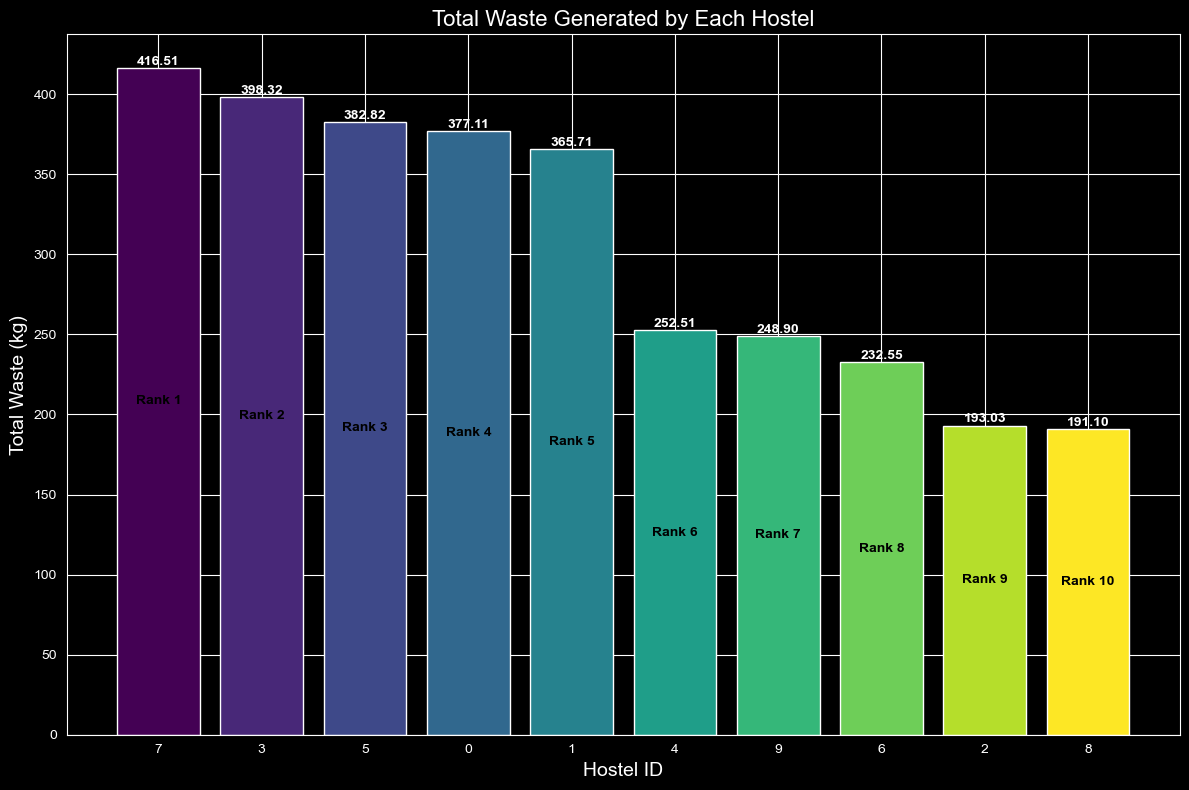

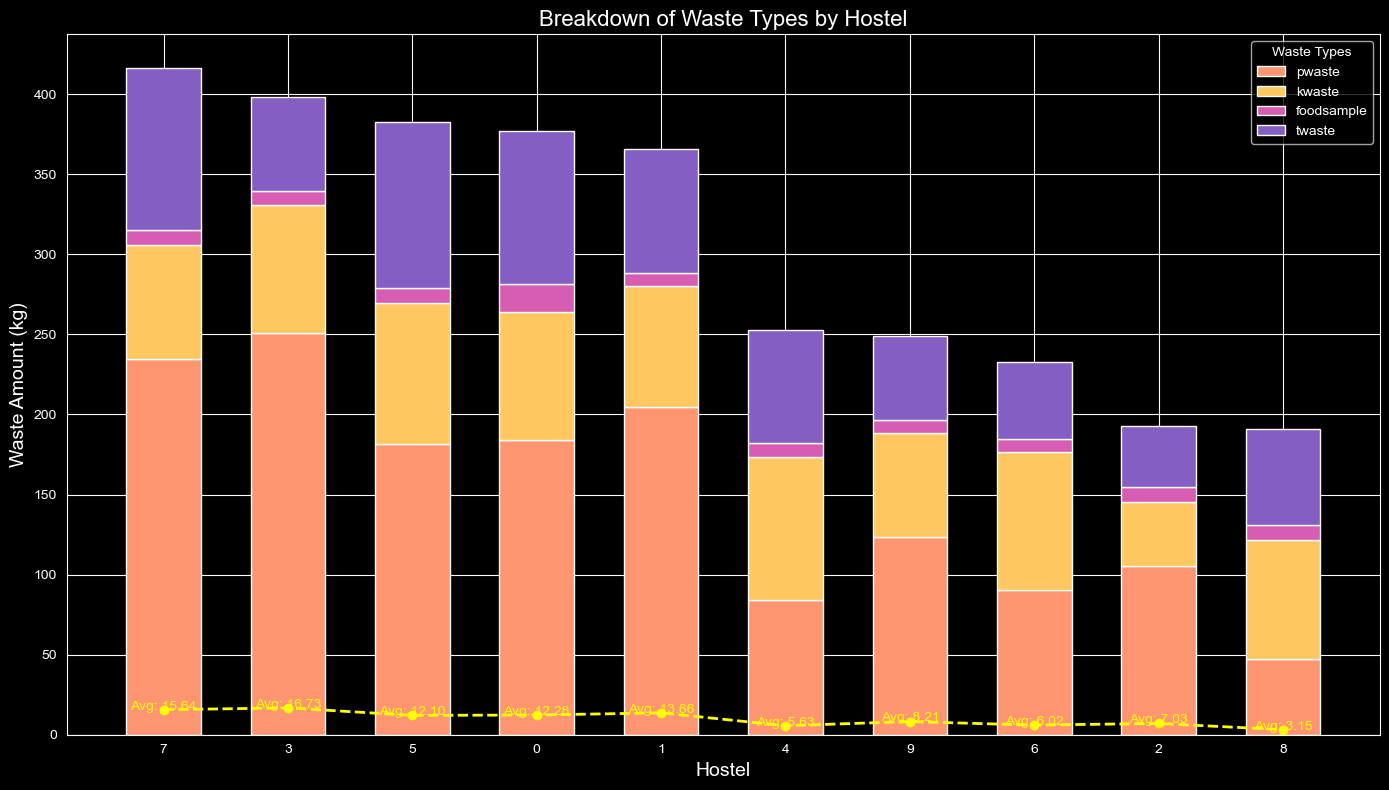

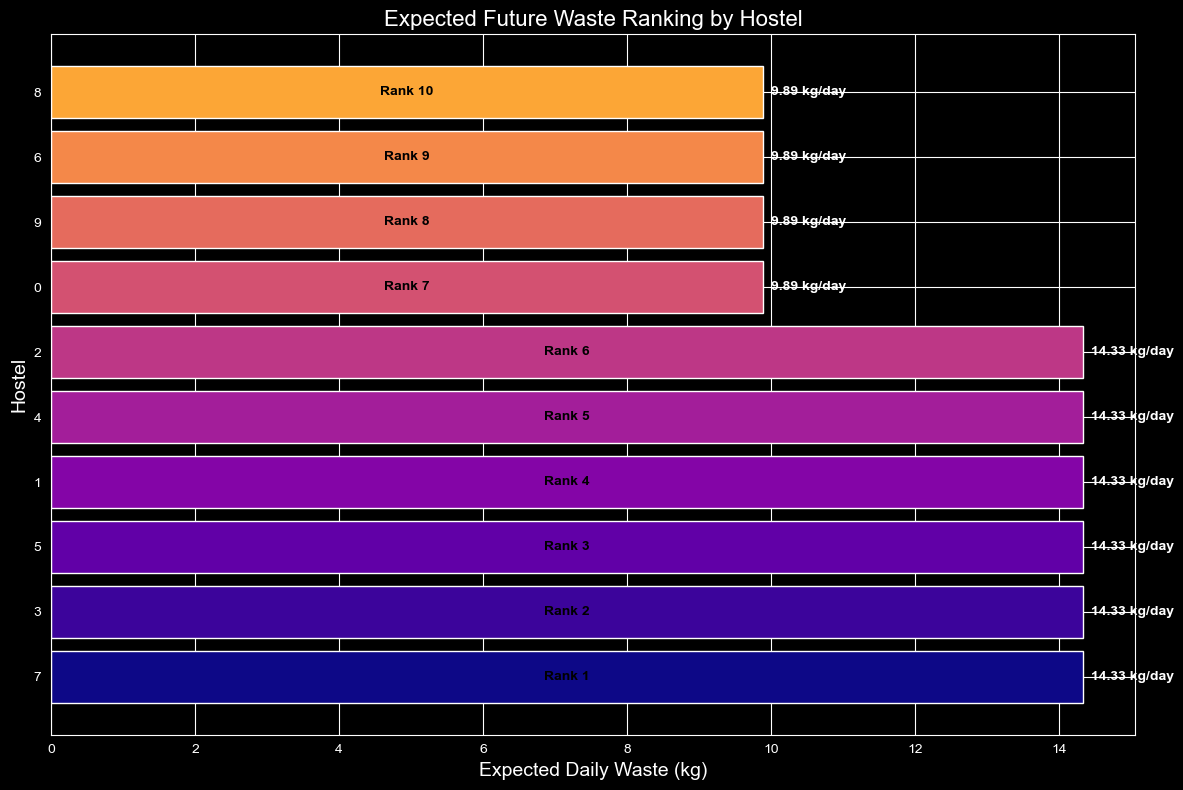


Waste Reduction Recommendations:

Hostel 7 Recommendations:
• MEDIUM PLATE WASTE: Review serving practices
• HIGHEST WASTE GENERATOR: Needs immediate attention


Hostel 3 Recommendations:
• HIGH PLATE WASTE: Consider reducing portion sizes
• Monitor student food preferences and adjust menu
• TOP 3 WASTE GENERATOR: Requires waste reduction plan


Hostel 5 Recommendations:
• MEDIUM PLATE WASTE: Review serving practices
• TOP 3 WASTE GENERATOR: Requires waste reduction plan


Hostel 0 Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel 1 Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel 4 Recommendations:


Hostel 9 Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel 6 Recommendations:


Hostel 2 Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel 8 Recommendations:



In [27]:
# CORRECTED HOSTEL WASTE RANKING ANALYSIS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# First, reset index if needed to get all columns
dataset_ranking = dataset.reset_index()

# Check if we have the original hostel identifier before binary encoding
if 'hostel' in dataset_ranking.columns:
    # Use original hostel identifiers if available
    hostel_column = 'hostel'
    hostels = dataset_ranking[hostel_column].unique()
    
    # Get total waste by hostel
    hostel_waste = dataset_ranking.groupby(hostel_column).agg({
        'pwaste': 'sum',
        'kwaste': 'sum',
        'foodsample': 'sum',
        'twaste': 'sum'
    }).reset_index()
    
    # Calculate total overall waste for each hostel
    hostel_waste['total_waste'] = hostel_waste['pwaste'] + hostel_waste['kwaste'] + \
                                 hostel_waste['foodsample'] + hostel_waste['twaste']
    
    # Sort by total waste (descending)
    hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)
    
else:
    # Since hostel column was binary encoded, we need to reconstruct hostel identifiers
    # First, let's identify the binary columns
    binary_cols = [col for col in dataset_ranking.columns if col.startswith('hostel_binary')]
    
    # Create a function to decode the binary encoding back to hostel IDs
    def decode_hostel_id(row):
        binary_string = ''
        for col in sorted(binary_cols):  # Sort to ensure correct order
            binary_string += str(int(row[col]))
        return int(binary_string, 2)  # Convert binary string to integer
    
    # Apply the decoding function to create a hostel ID column
    dataset_ranking['hostel_id'] = dataset_ranking.apply(decode_hostel_id, axis=1)
    
    # Get total waste by reconstructed hostel ID
    hostel_waste = dataset_ranking.groupby('hostel_id').agg({
        'pwaste': 'sum',
        'kwaste': 'sum',
        'foodsample': 'sum',
        'twaste': 'sum'
    }).reset_index()
    
    # Calculate total overall waste for each hostel
    hostel_waste['total_waste'] = hostel_waste['pwaste'] + hostel_waste['kwaste'] + \
                                 hostel_waste['foodsample'] + hostel_waste['twaste']
    
    # Sort by total waste (descending)
    hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)
    hostel_column = 'hostel_id'

# Use the original IDs directly as hostel names instead of mapping to letters
hostel_waste['hostel_name'] = hostel_waste[hostel_column].astype(str)

# Display the ranked results
print("Hostel Ranking by Total Waste Generation:")
print(hostel_waste[[hostel_column, 'hostel_name', 'total_waste']])

# Visualization for hostel rankings
plt.figure(figsize=(12, 8))
sns.set_style("darkgrid", {
    'axes.facecolor': 'black',
    'figure.facecolor': 'black',
    'grid.color': 'white'
})

# Create a bar chart showing total waste by hostel, using hostel IDs
bars = plt.bar(hostel_waste['hostel_name'], hostel_waste['total_waste'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(hostel_waste))))

# Add waste amount labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f}',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add labels and title
plt.title('Total Waste Generated by Each Hostel', color='white', fontsize=16)
plt.xlabel('Hostel ID', color='white', fontsize=14)
plt.ylabel('Total Waste (kg)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

# Add ranking numbers above bars
for i, (bar, waste) in enumerate(zip(bars, hostel_waste['total_waste'])):
    plt.text(bar.get_x() + bar.get_width()/2., waste/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

# BREAKDOWN ANALYSIS - Waste by hostel and type

# Create a stacked bar chart showing breakdown of waste types by hostel
plt.figure(figsize=(14, 8))

# Set up the bar positions
x = np.arange(len(hostel_waste))
width = 0.6

# Create the stacked bars
bottom_data = np.zeros(len(hostel_waste))

for waste_type, color in zip(['pwaste', 'kwaste', 'foodsample', 'twaste'], 
                            ['#FF9671', '#FFC75F', '#D65DB1', '#845EC2']):
    plt.bar(x, hostel_waste[waste_type], width, bottom=bottom_data, 
           label=waste_type, color=color)
    bottom_data += hostel_waste[waste_type]

# Customize the chart
plt.title('Breakdown of Waste Types by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Waste Amount (kg)', color='white', fontsize=14)
plt.xticks(x, hostel_waste['hostel_name'], color='white')
plt.yticks(color='white')

# Add a legend with white text
legend = plt.legend(title='Waste Types', loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

# Add expected values - average waste per meal
avg_waste_per_meal = dataset_ranking.groupby(hostel_column)['pwaste'].mean()
hostel_order = hostel_waste[hostel_column].tolist()
avg_values = [avg_waste_per_meal[h] if h in avg_waste_per_meal.index else 0 for h in hostel_order]

# Plot average line
avg_points = []
for i, avg in enumerate(avg_values):
    avg_points.append((i, avg))
    plt.text(i, avg + 0.1, f'Avg: {avg:.2f}', color='yellow', ha='center')

avg_x, avg_y = zip(*avg_points)
plt.plot(avg_x, avg_y, 'o--', color='yellow', linewidth=2, label='Avg waste/meal')

plt.tight_layout()
plt.show()

# PREDICTION: Expected future waste by hostel
# Use the prediction model we built earlier to forecast waste by hostel

# For each hostel, predict next 7 days of waste
meal_types = ['breakfast', 'lunch', 'dinner']
future_dates = [pd.Timestamp.now() + pd.Timedelta(days=i) for i in range(1, 8)]

# Create a dictionary to store predictions
hostel_predictions = {}

# For each hostel, predict waste for each meal type
for hostel_id in hostel_waste[hostel_column]:
    # Determine hostel type (boys/girls)
    if 'hostel type_boys' in dataset_ranking.columns and 'hostel type_girls' in dataset_ranking.columns:
        # Find which hostel type this hostel belongs to
        hostel_rows = dataset_ranking[dataset_ranking[hostel_column] == hostel_id]
        is_boys = hostel_rows['hostel type_boys'].iloc[0] if not hostel_rows.empty else 0
        hostel_type = 'boys' if is_boys else 'girls'
    else:
        # Default to 'boys' if we can't determine
        hostel_type = 'boys'
    
    # Collect predictions for all meals
    waste_values = []
    for date in future_dates:
        for meal in meal_types:
            # Call our prediction function and extract just the predicted waste value
            try:
                pred = predict_future_waste(meal, hostel_type, date)
                # Extract just the waste value from the dictionary
                if isinstance(pred, dict) and 'predicted_waste' in pred:
                    waste_values.append(pred['predicted_waste'])
                else:
                    # If somehow the prediction is a single value instead of dict
                    waste_values.append(float(pred))
            except Exception as e:
                print(f"Error predicting for hostel {hostel_id}, meal {meal}: {e}")
                continue
    
    # Store the average predicted waste for this hostel
    if waste_values:
        hostel_predictions[hostel_id] = np.mean(waste_values)
    else:
        # Fallback if predictions failed
        hostel_predictions[hostel_id] = hostel_waste.loc[hostel_waste[hostel_column] == hostel_id, 'pwaste'].mean()

# Convert to dataframe for visualization
predictions_df = pd.DataFrame({
    'Hostel': hostel_predictions.keys(),
    'Expected_Waste': hostel_predictions.values()
}).sort_values('Expected_Waste', ascending=False)

# Use the direct hostel IDs as names
predictions_df['Hostel_Name'] = predictions_df['Hostel'].astype(str)

# Create a horizontal bar chart showing expected waste ranking
plt.figure(figsize=(12, 8))

# Create horizontal bars with gradient colors based on waste amount
colors = plt.cm.plasma(np.linspace(0, 0.8, len(predictions_df)))
bars = plt.barh(predictions_df['Hostel_Name'], predictions_df['Expected_Waste'], color=colors)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.1, i, f'{width:.2f} kg/day', 
            ha='left', va='center', color='white', fontweight='bold')

# Add rank numbers inside bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width/2, i, f'Rank {i+1}', 
            ha='center', va='center', color='black', fontweight='bold')

# Customize the chart
plt.title('Expected Future Waste Ranking by Hostel', color='white', fontsize=16)
plt.xlabel('Expected Daily Waste (kg)', color='white', fontsize=14)
plt.ylabel('Hostel', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()

# WASTE REDUCTION RECOMMENDATIONS
# For each hostel, provide suggestions based on their waste patterns

hostel_recommendations = {}

for idx, row in hostel_waste.iterrows():
    hostel_id = row[hostel_column]
    hostel_name = row['hostel_name']
    total = row['total_waste']
    plate = row['pwaste']
    kitchen = row['kwaste']
    
    # Calculate percentages
    plate_pct = 100 * plate / total if total > 0 else 0
    kitchen_pct = 100 * kitchen / total if total > 0 else 0
    
    recommendation = f"Hostel {hostel_name} Recommendations:\n"
    
    if plate_pct > 60:
        recommendation += "• HIGH PLATE WASTE: Consider reducing portion sizes\n"
        recommendation += "• Monitor student food preferences and adjust menu\n"
    elif plate_pct > 40:
        recommendation += "• MEDIUM PLATE WASTE: Review serving practices\n"
    
    if kitchen_pct > 40:
        recommendation += "• HIGH KITCHEN WASTE: Improve food preparation methods\n"
        recommendation += "• Enhance inventory management to reduce spoilage\n"
    
    # Add general recommendation based on ranking
    rank = hostel_waste[hostel_column].tolist().index(hostel_id) + 1
    if rank == 1:
        recommendation += f"• HIGHEST WASTE GENERATOR: Needs immediate attention\n"
    elif rank <= 3:
        recommendation += f"• TOP 3 WASTE GENERATOR: Requires waste reduction plan\n"
    
    hostel_recommendations[hostel_name] = recommendation

print("\nWaste Reduction Recommendations:")
for hostel_name, recommendation in hostel_recommendations.items():
    print(f"\n{recommendation}")

In [31]:
# try

Hostel Ranking by Total Waste Generation:
   hostel_id hostel_name total_waste
7          7           O      416.51
3          3           D      398.32
5          5           M   382.82031
0          0           A      377.11
1          1           B      365.71
4          4         FRG      252.51
9          9           Q       248.9
6          6           N    232.5505
2          2           C     193.031
8          8          PG       191.1


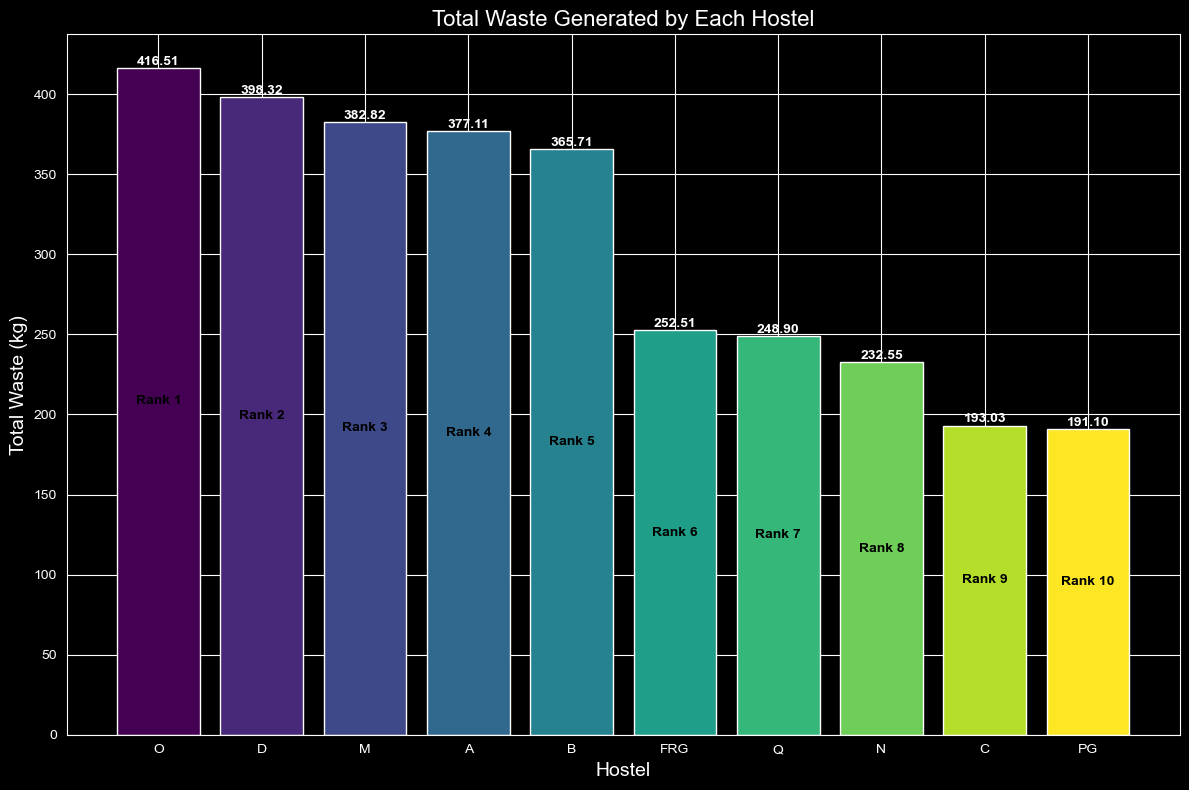

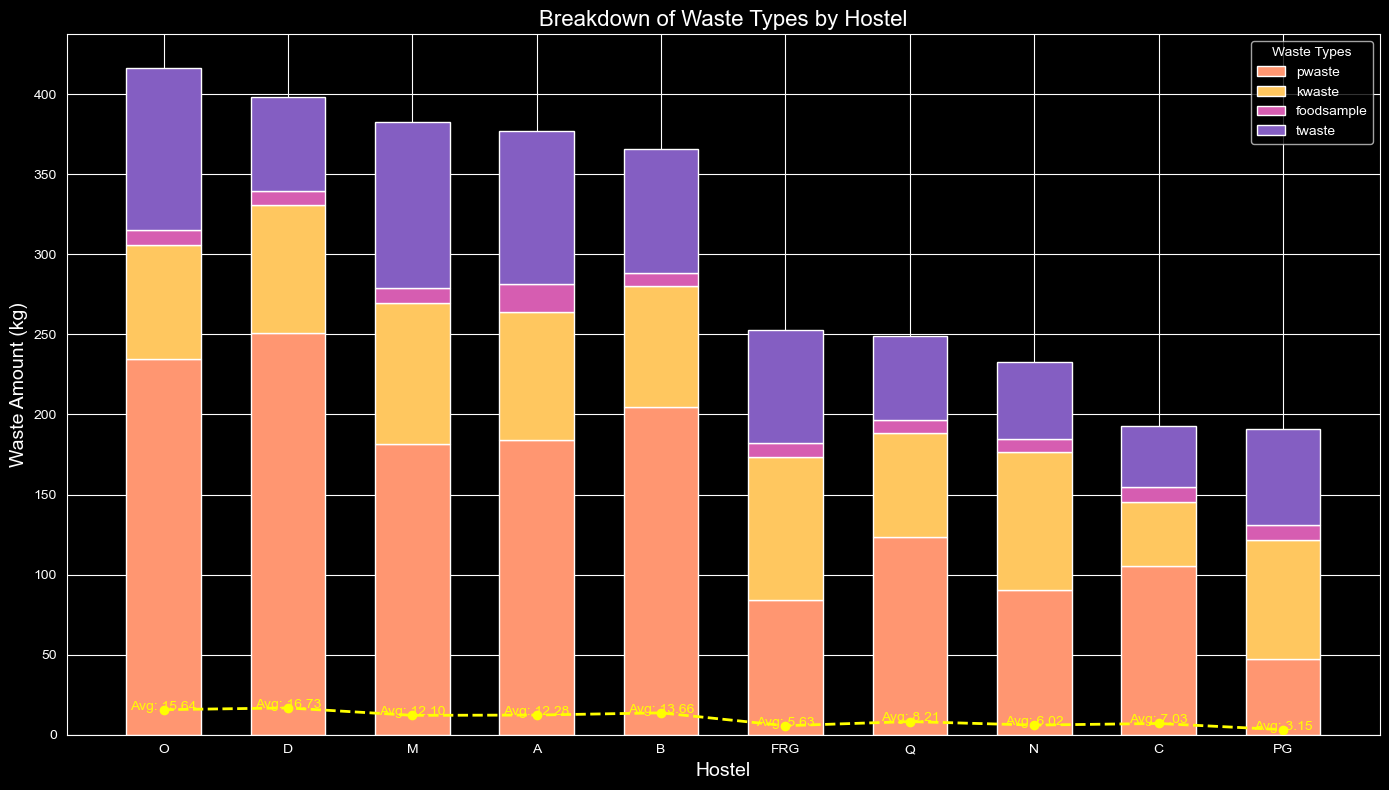

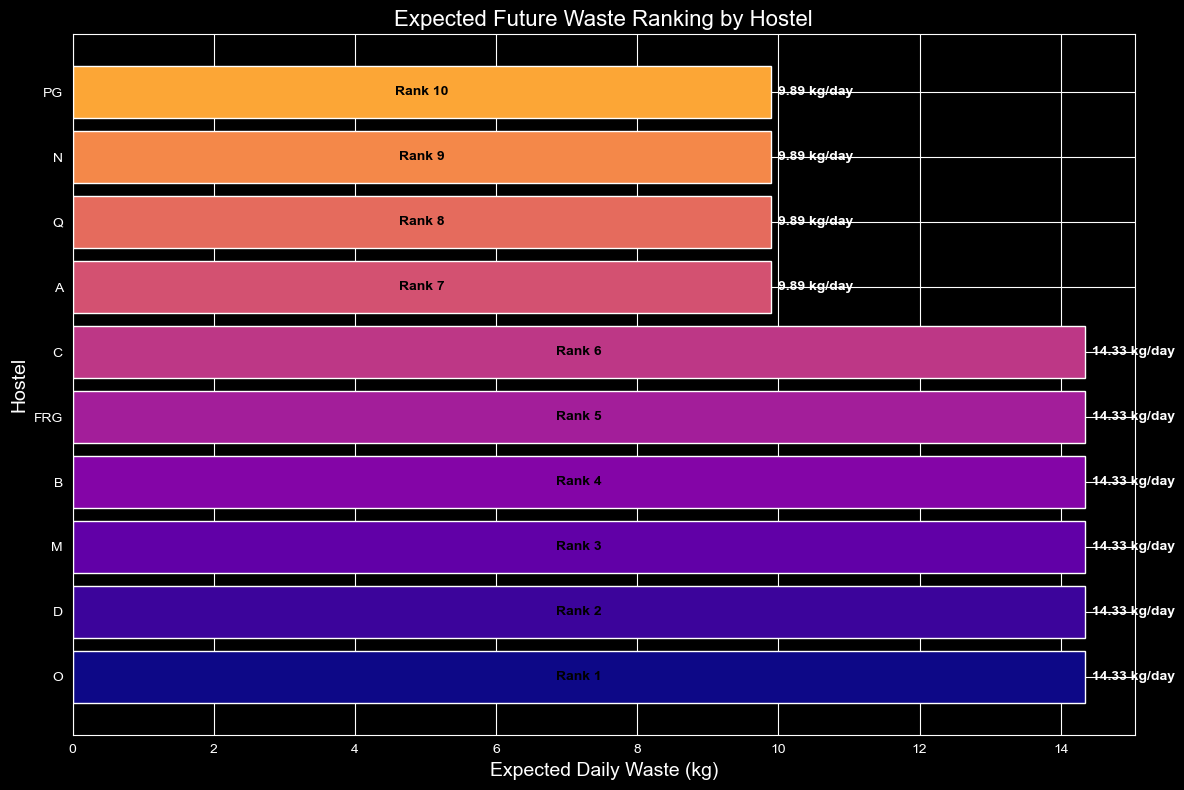


Waste Reduction Recommendations:

Hostel O Recommendations:
• MEDIUM PLATE WASTE: Review serving practices
• HIGHEST WASTE GENERATOR: Needs immediate attention


Hostel D Recommendations:
• HIGH PLATE WASTE: Consider reducing portion sizes
• Monitor student food preferences and adjust menu
• TOP 3 WASTE GENERATOR: Requires waste reduction plan


Hostel M Recommendations:
• MEDIUM PLATE WASTE: Review serving practices
• TOP 3 WASTE GENERATOR: Requires waste reduction plan


Hostel A Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel B Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel FRG Recommendations:


Hostel Q Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel N Recommendations:


Hostel C Recommendations:
• MEDIUM PLATE WASTE: Review serving practices


Hostel PG Recommendations:



In [32]:
# HOSTEL WASTE RANKING ANALYSIS WITH CORRECT NAMES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# First, reset index if needed to get all columns
dataset_ranking = dataset.reset_index()

# Define the correct hostel names in their original order
correct_hostel_names = ["A", "B", "C", "D", "FRG", "M", "N", "O", "PG", "Q"]

# Check if we have the original hostel identifier before binary encoding
if 'hostel' in dataset_ranking.columns:
    # Use original hostel identifiers if available
    hostel_column = 'hostel'
    unique_hostels = sorted(dataset_ranking[hostel_column].unique())
    
    # Create a mapping from dataset hostel IDs to correct names
    hostel_name_map = {}
    for i, hostel_id in enumerate(unique_hostels):
        if i < len(correct_hostel_names):
            hostel_name_map[hostel_id] = correct_hostel_names[i]
        else:
            hostel_name_map[hostel_id] = str(hostel_id)
    
    # Get total waste by hostel
    hostel_waste = dataset_ranking.groupby(hostel_column).agg({
        'pwaste': 'sum',
        'kwaste': 'sum',
        'foodsample': 'sum',
        'twaste': 'sum'
    }).reset_index()
    
    # Calculate total overall waste for each hostel
    hostel_waste['total_waste'] = hostel_waste['pwaste'] + hostel_waste['kwaste'] + \
                                 hostel_waste['foodsample'] + hostel_waste['twaste']
    
    # Add the correct hostel names
    hostel_waste['hostel_name'] = hostel_waste[hostel_column].map(hostel_name_map)
    
    # Sort by total waste (descending)
    hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)
    
else:
    # Since hostel column was binary encoded, we need to reconstruct hostel identifiers
    binary_cols = [col for col in dataset_ranking.columns if col.startswith('hostel_binary')]
    
    # Create a function to decode the binary encoding back to hostel IDs
    def decode_hostel_id(row):
        binary_string = ''
        for col in sorted(binary_cols):  # Sort to ensure correct order
            binary_string += str(int(row[col]))
        return int(binary_string, 2)  # Convert binary string to integer
    
    # Apply the decoding function to create a hostel ID column
    dataset_ranking['hostel_id'] = dataset_ranking.apply(decode_hostel_id, axis=1)
    
    # Get total waste by reconstructed hostel ID
    hostel_waste = dataset_ranking.groupby('hostel_id').agg({
        'pwaste': 'sum',
        'kwaste': 'sum',
        'foodsample': 'sum',
        'twaste': 'sum'
    }).reset_index()
    
    # Calculate total overall waste for each hostel
    hostel_waste['total_waste'] = hostel_waste['pwaste'] + hostel_waste['kwaste'] + \
                                 hostel_waste['foodsample'] + hostel_waste['twaste']
    
    # Create a mapping from numeric IDs to correct hostel names
    unique_hostels = sorted(hostel_waste['hostel_id'].unique())
    hostel_name_map = {}
    for i, hostel_id in enumerate(unique_hostels):
        if i < len(correct_hostel_names):
            hostel_name_map[hostel_id] = correct_hostel_names[i]
        else:
            hostel_name_map[hostel_id] = str(hostel_id)
    
    # Add the correct hostel names
    hostel_waste['hostel_name'] = hostel_waste['hostel_id'].map(hostel_name_map)
    
    # Sort by total waste (descending)
    hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)
    hostel_column = 'hostel_id'

# Display the ranked results with correct names
print("Hostel Ranking by Total Waste Generation:")
print(hostel_waste[[hostel_column, 'hostel_name', 'total_waste']])

# Visualization for hostel rankings
plt.figure(figsize=(12, 8))
sns.set_style("darkgrid", {
    'axes.facecolor': 'black',
    'figure.facecolor': 'black',
    'grid.color': 'white'
})

# Create a bar chart showing total waste by hostel
bars = plt.bar(hostel_waste['hostel_name'], hostel_waste['total_waste'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(hostel_waste))))

# Add waste amount labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f}',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add labels and title
plt.title('Total Waste Generated by Each Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Total Waste (kg)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

# Add ranking numbers above bars
for i, (bar, waste) in enumerate(zip(bars, hostel_waste['total_waste'])):
    plt.text(bar.get_x() + bar.get_width()/2., waste/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

# BREAKDOWN ANALYSIS - Waste by hostel and type
plt.figure(figsize=(14, 8))

# Set up the bar positions
x = np.arange(len(hostel_waste))
width = 0.6

# Create the stacked bars
bottom_data = np.zeros(len(hostel_waste))

for waste_type, color in zip(['pwaste', 'kwaste', 'foodsample', 'twaste'], 
                            ['#FF9671', '#FFC75F', '#D65DB1', '#845EC2']):
    plt.bar(x, hostel_waste[waste_type], width, bottom=bottom_data, 
           label=waste_type, color=color)
    bottom_data += hostel_waste[waste_type]

# Customize the chart
plt.title('Breakdown of Waste Types by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Waste Amount (kg)', color='white', fontsize=14)
plt.xticks(x, hostel_waste['hostel_name'], color='white')
plt.yticks(color='white')

# Add a legend with white text
legend = plt.legend(title='Waste Types', loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

# Add expected values - average waste per meal
avg_waste_per_meal = dataset_ranking.groupby(hostel_column)['pwaste'].mean()
hostel_order = hostel_waste[hostel_column].tolist()
avg_values = [avg_waste_per_meal[h] if h in avg_waste_per_meal.index else 0 for h in hostel_order]

# Plot average line
avg_points = []
for i, avg in enumerate(avg_values):
    avg_points.append((i, avg))
    plt.text(i, avg + 0.1, f'Avg: {avg:.2f}', color='yellow', ha='center')

avg_x, avg_y = zip(*avg_points)
plt.plot(avg_x, avg_y, 'o--', color='yellow', linewidth=2, label='Avg waste/meal')

plt.tight_layout()
plt.show()

# PREDICTION: Expected future waste by hostel
meal_types = ['breakfast', 'lunch', 'dinner']
future_dates = [pd.Timestamp.now() + pd.Timedelta(days=i) for i in range(1, 8)]

# Create a dictionary to store predictions
hostel_predictions = {}

# For each hostel, predict waste for each meal type
for idx, row in hostel_waste.iterrows():
    hostel_id = row[hostel_column]
    hostel_name = row['hostel_name']
    
    # Determine hostel type (boys/girls)
    if 'hostel type_boys' in dataset_ranking.columns and 'hostel type_girls' in dataset_ranking.columns:
        # Find which hostel type this hostel belongs to
        hostel_rows = dataset_ranking[dataset_ranking[hostel_column] == hostel_id]
        is_boys = hostel_rows['hostel type_boys'].iloc[0] if not hostel_rows.empty else 0
        hostel_type = 'boys' if is_boys else 'girls'
    else:
        # Default to 'boys' if we can't determine
        hostel_type = 'boys'
    
    # Collect predictions for all meals
    waste_values = []
    for date in future_dates:
        for meal in meal_types:
            # Call our prediction function and extract just the predicted waste value
            try:
                pred = predict_future_waste(meal, hostel_type, date)
                # Extract just the waste value from the dictionary
                if isinstance(pred, dict) and 'predicted_waste' in pred:
                    waste_values.append(pred['predicted_waste'])
                else:
                    # If somehow the prediction is a single value instead of dict
                    waste_values.append(float(pred))
            except Exception as e:
                print(f"Error predicting for hostel {hostel_name}, meal {meal}: {e}")
                continue
    
    # Store the average predicted waste for this hostel
    if waste_values:
        hostel_predictions[hostel_name] = np.mean(waste_values)
    else:
        # Fallback if predictions failed
        hostel_predictions[hostel_name] = row['pwaste']

# Convert to dataframe for visualization
predictions_df = pd.DataFrame({
    'Hostel': list(hostel_predictions.keys()),
    'Expected_Waste': list(hostel_predictions.values())
}).sort_values('Expected_Waste', ascending=False)

# Create a horizontal bar chart showing expected waste ranking
plt.figure(figsize=(12, 8))

# Create horizontal bars with gradient colors based on waste amount
colors = plt.cm.plasma(np.linspace(0, 0.8, len(predictions_df)))
bars = plt.barh(predictions_df['Hostel'], predictions_df['Expected_Waste'], color=colors)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.1, i, f'{width:.2f} kg/day', 
            ha='left', va='center', color='white', fontweight='bold')

# Add rank numbers inside bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width/2, i, f'Rank {i+1}', 
            ha='center', va='center', color='black', fontweight='bold')

# Customize the chart
plt.title('Expected Future Waste Ranking by Hostel', color='white', fontsize=16)
plt.xlabel('Expected Daily Waste (kg)', color='white', fontsize=14)
plt.ylabel('Hostel', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()

# WASTE REDUCTION RECOMMENDATIONS
hostel_recommendations = {}

for idx, row in hostel_waste.iterrows():
    hostel_name = row['hostel_name']
    total = row['total_waste']
    plate = row['pwaste']
    kitchen = row['kwaste']
    
    # Calculate percentages
    plate_pct = 100 * plate / total if total > 0 else 0
    kitchen_pct = 100 * kitchen / total if total > 0 else 0
    
    recommendation = f"Hostel {hostel_name} Recommendations:\n"
    
    if plate_pct > 60:
        recommendation += "• HIGH PLATE WASTE: Consider reducing portion sizes\n"
        recommendation += "• Monitor student food preferences and adjust menu\n"
    elif plate_pct > 40:
        recommendation += "• MEDIUM PLATE WASTE: Review serving practices\n"
    
    if kitchen_pct > 40:
        recommendation += "• HIGH KITCHEN WASTE: Improve food preparation methods\n"
        recommendation += "• Enhance inventory management to reduce spoilage\n"
    
    # Add general recommendation based on ranking
    rank = predictions_df[predictions_df['Hostel'] == hostel_name].index[0] + 1 if hostel_name in predictions_df['Hostel'].values else -1
    if rank == 1:
        recommendation += f"• HIGHEST WASTE GENERATOR: Needs immediate attention\n"
    elif rank <= 3:
        recommendation += f"• TOP 3 WASTE GENERATOR: Requires waste reduction plan\n"
    
    hostel_recommendations[hostel_name] = recommendation

print("\nWaste Reduction Recommendations:")
for hostel_name, recommendation in hostel_recommendations.items():
    print(f"\n{recommendation}")

In [ ]:
# first find plate waste then ratio of plate waste to all other waste then plot

Hostel Ranking by Total Waste Generation:
   hostel_id hostel_name total_waste
7          7           O      416.51
3          3           D      398.32
5          5           M   382.82031
0          0           A      377.11
1          1           B      365.71
4          4         FRG      252.51
9          9           Q       248.9
6          6           N    232.5505
2          2           C     193.031
8          8          PG       191.1


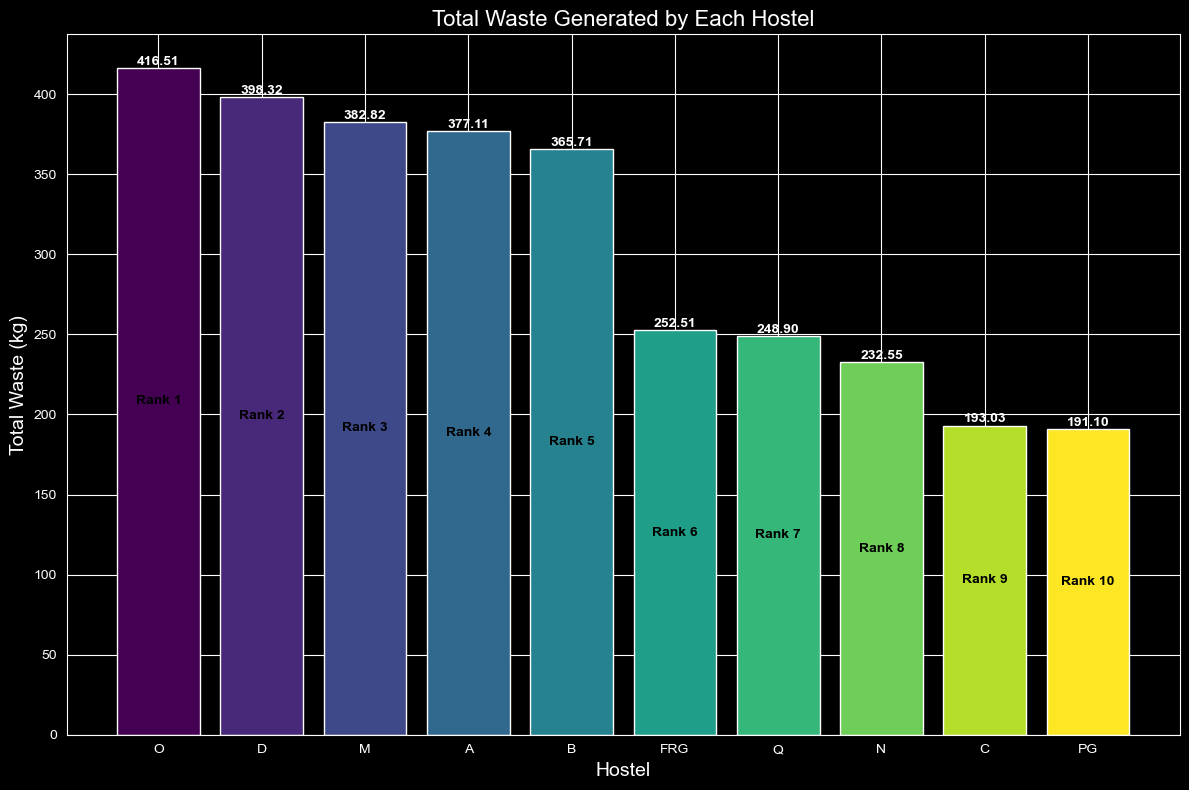

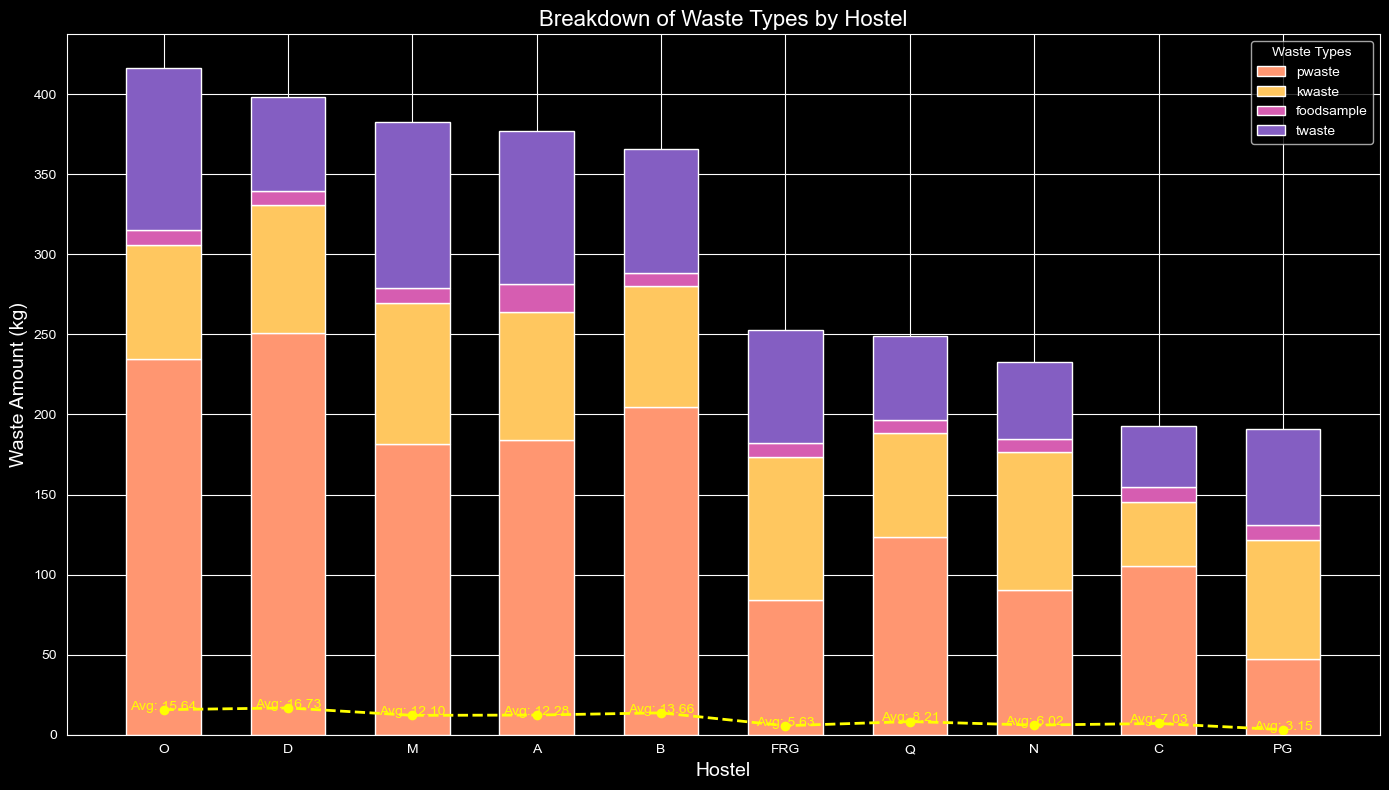

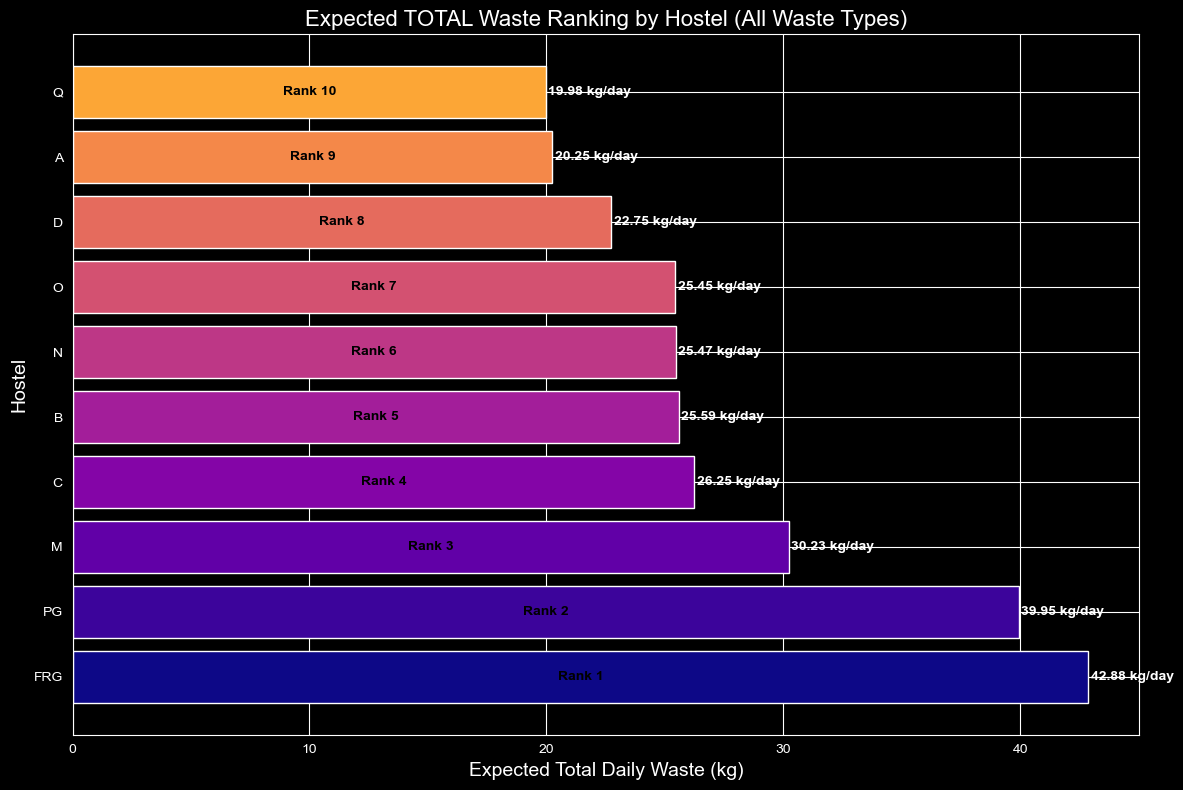


Waste Reduction Recommendations:

Hostel O Recommendations:
• MEDIUM PLATE WASTE: Review serving practices
• HIGHEST WASTE GENERATOR: Needs immediate attention
• EXPECTED TOTAL WASTE: 25.45 kg/day


Hostel D Recommendations:
• HIGH PLATE WASTE: Consider reducing portion sizes
• Monitor student food preferences and adjust menu
• TOP 3 WASTE GENERATOR: Requires waste reduction plan
• EXPECTED TOTAL WASTE: 22.75 kg/day


Hostel M Recommendations:
• MEDIUM PLATE WASTE: Review serving practices
• TOP 3 WASTE GENERATOR: Requires waste reduction plan
• EXPECTED TOTAL WASTE: 30.23 kg/day


Hostel A Recommendations:
• MEDIUM PLATE WASTE: Review serving practices
• EXPECTED TOTAL WASTE: 20.25 kg/day


Hostel B Recommendations:
• MEDIUM PLATE WASTE: Review serving practices
• EXPECTED TOTAL WASTE: 25.59 kg/day


Hostel FRG Recommendations:
• EXPECTED TOTAL WASTE: 42.88 kg/day


Hostel Q Recommendations:
• MEDIUM PLATE WASTE: Review serving practices
• EXPECTED TOTAL WASTE: 19.98 kg/day


Hostel 

In [33]:
# HOSTEL WASTE RANKING ANALYSIS WITH CORRECT NAMES AND TOTAL WASTE PREDICTION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# First, reset index if needed to get all columns
dataset_ranking = dataset.reset_index()

# Define the correct hostel names in their original order
correct_hostel_names = ["A", "B", "C", "D", "FRG", "M", "N", "O", "PG", "Q"]

# Check if we have the original hostel identifier before binary encoding
if 'hostel' in dataset_ranking.columns:
    # Use original hostel identifiers if available
    hostel_column = 'hostel'
    unique_hostels = sorted(dataset_ranking[hostel_column].unique())
    
    # Create a mapping from dataset hostel IDs to correct names
    hostel_name_map = {}
    for i, hostel_id in enumerate(unique_hostels):
        if i < len(correct_hostel_names):
            hostel_name_map[hostel_id] = correct_hostel_names[i]
        else:
            hostel_name_map[hostel_id] = str(hostel_id)
    
    # Get total waste by hostel
    hostel_waste = dataset_ranking.groupby(hostel_column).agg({
        'pwaste': 'sum',
        'kwaste': 'sum',
        'foodsample': 'sum',
        'twaste': 'sum'
    }).reset_index()
    
    # Calculate total overall waste for each hostel
    hostel_waste['total_waste'] = hostel_waste['pwaste'] + hostel_waste['kwaste'] + \
                                 hostel_waste['foodsample'] + hostel_waste['twaste']
    
    # Add the correct hostel names
    hostel_waste['hostel_name'] = hostel_waste[hostel_column].map(hostel_name_map)
    
    # Sort by total waste (descending)
    hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)
    
else:
    # Since hostel column was binary encoded, we need to reconstruct hostel identifiers
    binary_cols = [col for col in dataset_ranking.columns if col.startswith('hostel_binary')]
    
    # Create a function to decode the binary encoding back to hostel IDs
    def decode_hostel_id(row):
        binary_string = ''
        for col in sorted(binary_cols):  # Sort to ensure correct order
            binary_string += str(int(row[col]))
        return int(binary_string, 2)  # Convert binary string to integer
    
    # Apply the decoding function to create a hostel ID column
    dataset_ranking['hostel_id'] = dataset_ranking.apply(decode_hostel_id, axis=1)
    
    # Get total waste by reconstructed hostel ID
    hostel_waste = dataset_ranking.groupby('hostel_id').agg({
        'pwaste': 'sum',
        'kwaste': 'sum',
        'foodsample': 'sum',
        'twaste': 'sum'
    }).reset_index()
    
    # Calculate total overall waste for each hostel
    hostel_waste['total_waste'] = hostel_waste['pwaste'] + hostel_waste['kwaste'] + \
                                 hostel_waste['foodsample'] + hostel_waste['twaste']
    
    # Create a mapping from numeric IDs to correct hostel names
    unique_hostels = sorted(hostel_waste['hostel_id'].unique())
    hostel_name_map = {}
    for i, hostel_id in enumerate(unique_hostels):
        if i < len(correct_hostel_names):
            hostel_name_map[hostel_id] = correct_hostel_names[i]
        else:
            hostel_name_map[hostel_id] = str(hostel_id)
    
    # Add the correct hostel names
    hostel_waste['hostel_name'] = hostel_waste['hostel_id'].map(hostel_name_map)
    
    # Sort by total waste (descending)
    hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)
    hostel_column = 'hostel_id'

# Display the ranked results with correct names
print("Hostel Ranking by Total Waste Generation:")
print(hostel_waste[[hostel_column, 'hostel_name', 'total_waste']])

# Visualization for hostel rankings
plt.figure(figsize=(12, 8))
sns.set_style("darkgrid", {
    'axes.facecolor': 'black',
    'figure.facecolor': 'black',
    'grid.color': 'white'
})

# Create a bar chart showing total waste by hostel
bars = plt.bar(hostel_waste['hostel_name'], hostel_waste['total_waste'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(hostel_waste))))

# Add waste amount labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f}',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add labels and title
plt.title('Total Waste Generated by Each Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Total Waste (kg)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

# Add ranking numbers above bars
for i, (bar, waste) in enumerate(zip(bars, hostel_waste['total_waste'])):
    plt.text(bar.get_x() + bar.get_width()/2., waste/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

# BREAKDOWN ANALYSIS - Waste by hostel and type
plt.figure(figsize=(14, 8))

# Set up the bar positions
x = np.arange(len(hostel_waste))
width = 0.6

# Create the stacked bars
bottom_data = np.zeros(len(hostel_waste))

for waste_type, color in zip(['pwaste', 'kwaste', 'foodsample', 'twaste'], 
                            ['#FF9671', '#FFC75F', '#D65DB1', '#845EC2']):
    plt.bar(x, hostel_waste[waste_type], width, bottom=bottom_data, 
           label=waste_type, color=color)
    bottom_data += hostel_waste[waste_type]

# Customize the chart
plt.title('Breakdown of Waste Types by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Waste Amount (kg)', color='white', fontsize=14)
plt.xticks(x, hostel_waste['hostel_name'], color='white')
plt.yticks(color='white')

# Add a legend with white text
legend = plt.legend(title='Waste Types', loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

# Add expected values - average waste per meal
avg_waste_per_meal = dataset_ranking.groupby(hostel_column)['pwaste'].mean()
hostel_order = hostel_waste[hostel_column].tolist()
avg_values = [avg_waste_per_meal[h] if h in avg_waste_per_meal.index else 0 for h in hostel_order]

# Plot average line
avg_points = []
for i, avg in enumerate(avg_values):
    avg_points.append((i, avg))
    plt.text(i, avg + 0.1, f'Avg: {avg:.2f}', color='yellow', ha='center')

avg_x, avg_y = zip(*avg_points)
plt.plot(avg_x, avg_y, 'o--', color='yellow', linewidth=2, label='Avg waste/meal')

plt.tight_layout()
plt.show()

# PREDICTION: Expected TOTAL waste by hostel (considering ALL waste types)
meal_types = ['breakfast', 'lunch', 'dinner']
future_dates = [pd.Timestamp.now() + pd.Timedelta(days=i) for i in range(1, 8)]

# Calculate waste type ratios for each hostel (how other waste types relate to plate waste)
waste_ratios = {}
for idx, row in hostel_waste.iterrows():
    hostel_id = row[hostel_column]
    hostel_name = row['hostel_name']
    
    if row['pwaste'] > 0:  # Avoid division by zero
        waste_ratios[hostel_name] = {
            'kwaste_ratio': row['kwaste'] / row['pwaste'],
            'foodsample_ratio': row['foodsample'] / row['pwaste'],
            'twaste_ratio': row['twaste'] / row['pwaste']
        }
    else:
        # Default ratios if no plate waste data
        waste_ratios[hostel_name] = {
            'kwaste_ratio': 1.0,
            'foodsample_ratio': 0.5,
            'twaste_ratio': 1.5
        }

# Create a dictionary to store predictions for TOTAL waste
hostel_predictions = {}

# For each hostel, predict waste for each meal type
for idx, row in hostel_waste.iterrows():
    hostel_id = row[hostel_column]
    hostel_name = row['hostel_name']
    
    # Determine hostel type (boys/girls)
    if 'hostel type_boys' in dataset_ranking.columns and 'hostel type_girls' in dataset_ranking.columns:
        # Find which hostel type this hostel belongs to
        hostel_rows = dataset_ranking[dataset_ranking[hostel_column] == hostel_id]
        is_boys = hostel_rows['hostel type_boys'].iloc[0] if not hostel_rows.empty else 0
        hostel_type = 'boys' if is_boys else 'girls'
    else:
        # Default to 'boys' if we can't determine
        hostel_type = 'boys'
    
    # Collect predictions for all meals
    total_waste_predictions = []
    
    for date in future_dates:
        for meal in meal_types:
            # First predict plate waste using our model
            try:
                pred = predict_future_waste(meal, hostel_type, date)
                
                # Extract just the waste value from the dictionary
                if isinstance(pred, dict) and 'predicted_waste' in pred:
                    plate_waste = pred['predicted_waste']
                else:
                    # If somehow the prediction is a single value instead of dict
                    plate_waste = float(pred)
                
                # Use the ratios to estimate other waste types
                ratios = waste_ratios[hostel_name]
                kitchen_waste = plate_waste * ratios['kwaste_ratio']
                food_sample = plate_waste * ratios['foodsample_ratio']
                total_waste = plate_waste * ratios['twaste_ratio']
                
                # Calculate the sum of ALL waste types for this prediction
                all_waste = plate_waste + kitchen_waste + food_sample + total_waste
                
                total_waste_predictions.append(all_waste)
                
            except Exception as e:
                print(f"Error predicting for hostel {hostel_name}, meal {meal}: {e}")
                continue
    
    # Store the average predicted TOTAL waste for this hostel
    if total_waste_predictions:
        hostel_predictions[hostel_name] = np.mean(total_waste_predictions)
    else:
        # Fallback if predictions failed: use historical total waste per day
        days_in_data = dataset_ranking['date'].nunique()
        if days_in_data > 0:
            hostel_predictions[hostel_name] = row['total_waste'] / days_in_data
        else:
            hostel_predictions[hostel_name] = row['total_waste'] / 30  # Assume data is for a month

# Convert to dataframe for visualization
predictions_df = pd.DataFrame({
    'Hostel': list(hostel_predictions.keys()),
    'Expected_Total_Waste': list(hostel_predictions.values())
}).sort_values('Expected_Total_Waste', ascending=False)

# Create a horizontal bar chart showing expected total waste ranking
plt.figure(figsize=(12, 8))

# Create horizontal bars with gradient colors based on waste amount
colors = plt.cm.plasma(np.linspace(0, 0.8, len(predictions_df)))
bars = plt.barh(predictions_df['Hostel'], predictions_df['Expected_Total_Waste'], color=colors)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.1, i, f'{width:.2f} kg/day', 
            ha='left', va='center', color='white', fontweight='bold')

# Add rank numbers inside bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width/2, i, f'Rank {i+1}', 
            ha='center', va='center', color='black', fontweight='bold')

# Customize the chart
plt.title('Expected TOTAL Waste Ranking by Hostel (All Waste Types)', color='white', fontsize=16)
plt.xlabel('Expected Total Daily Waste (kg)', color='white', fontsize=14)
plt.ylabel('Hostel', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()

# WASTE REDUCTION RECOMMENDATIONS
hostel_recommendations = {}

for idx, row in hostel_waste.iterrows():
    hostel_name = row['hostel_name']
    total = row['total_waste']
    plate = row['pwaste']
    kitchen = row['kwaste']
    
    # Calculate percentages
    plate_pct = 100 * plate / total if total > 0 else 0
    kitchen_pct = 100 * kitchen / total if total > 0 else 0
    
    recommendation = f"Hostel {hostel_name} Recommendations:\n"
    
    if plate_pct > 60:
        recommendation += "• HIGH PLATE WASTE: Consider reducing portion sizes\n"
        recommendation += "• Monitor student food preferences and adjust menu\n"
    elif plate_pct > 40:
        recommendation += "• MEDIUM PLATE WASTE: Review serving practices\n"
    
    if kitchen_pct > 40:
        recommendation += "• HIGH KITCHEN WASTE: Improve food preparation methods\n"
        recommendation += "• Enhance inventory management to reduce spoilage\n"
    
    # Add general recommendation based on ranking
    rank = predictions_df[predictions_df['Hostel'] == hostel_name].index[0] + 1 if hostel_name in predictions_df['Hostel'].values else -1
    if rank == 1:
        recommendation += f"• HIGHEST WASTE GENERATOR: Needs immediate attention\n"
    elif rank <= 3:
        recommendation += f"• TOP 3 WASTE GENERATOR: Requires waste reduction plan\n"
    
    # Add expected total waste
    if hostel_name in predictions_df['Hostel'].values:
        expected_waste = predictions_df.loc[predictions_df['Hostel'] == hostel_name, 'Expected_Total_Waste'].values[0]
        recommendation += f"• EXPECTED TOTAL WASTE: {expected_waste:.2f} kg/day\n"
    
    hostel_recommendations[hostel_name] = recommendation

print("\nWaste Reduction Recommendations:")
for hostel_name, recommendation in hostel_recommendations.items():
    print(f"\n{recommendation}")